In [99]:
import json
import numpy as np
import pandas as pd
import os

### Derriving mapping

In [100]:
with open("cfsort_full_map_dict_v2.json", "rb") as f:
    tissue_mapping_dict = json.load(f)

In [101]:
LOYFER_CONFIDENCE_LEVELS = [
    "loyfer_counts_manual_legacy",
    "loyfer_counts_ontology_and_manual",  # Exact Ontology match + hierarchical match + manual curation. WARNING: Produces spurious matches, hence, unusable.
    "loyfer_counts_lenient",  # Exact Ontology match + hierarchical match + manual curation + match by keyword. WARNING: Produces spurious matches, hence, unusable.
    "loyfer_counts_strict",  # Exact Ontology match + manual curation
]

In [102]:
def get_expected_cell_types(
    tissue_dict,
    threshold,
    exclude_keys=("unmapped",),
    loyfer_confidence_level="loyfer_counts_ontology_and_manual",
):
    """
    Build a DataFrame of expected cell types per tissue based on a loyfer_counts
    percentage threshold.

    Parameters
    ----------
    tissue_dict : dict
        Dictionary keyed by tissue name (cfsort_name), with each value containing
        a loyfer_confidence_level sub-dict.
    threshold : float
        Minimum percentage (0-1 scale, e.g. 0.05 for 5%) a cell type must reach
        to be included in expected_cell_types.
    exclude_keys : tuple of str
        Keys to always exclude from consideration (default: ('unmapped',)).

    Returns
    -------
    pd.DataFrame
        Columns: cfsort_tissue_name, expected_cell_types, final_mapping_rate
    """
    rows = []
    for tissue_name, tissue_data in tissue_dict.items():
        loyfer_counts = tissue_data.get(loyfer_confidence_level, {}) or {}

        # Filter out excluded keys before computing the total so percentages
        # are relative to the "mappable" pool. If you'd rather keep 'unmapped'
        # in the denominator, move this filtering to after the total is computed.
        filtered = {k: v for k, v in loyfer_counts.items() if k not in exclude_keys}

        total = sum(loyfer_counts.values())

        if total == 0:
            rows.append(
                {
                    "cfsort_tissue_name": tissue_name,
                    "expected_cell_types": [],
                    "final_mapping_rate": 0.0,
                }
            )
            continue

        # Build (cell_type, percentage) pairs and filter by threshold
        passing = [
            (ct, cnt / total)
            for ct, cnt in filtered.items()
            if (cnt / total) >= threshold
        ]

        # Sort by percentage descending for readability
        passing.sort(key=lambda x: x[1], reverse=True)

        expected_cell_types = [ct for ct, _ in passing]
        final_mapping_rate = round(sum(p for _, p in passing), 4)

        rows.append(
            {
                "cfsort_tissue_name": tissue_name,
                "expected_cell_types": expected_cell_types,
                "final_mapping_rate": final_mapping_rate,
            }
        )

    return pd.DataFrame(
        rows,
        columns=["cfsort_tissue_name", "expected_cell_types", "final_mapping_rate"],
    )

In [103]:
tissue_mapping_df = get_expected_cell_types(
    tissue_dict=tissue_mapping_dict,
    threshold=0.01,
    loyfer_confidence_level="loyfer_counts_strict",
)
tissue_mapping_df = tissue_mapping_df[tissue_mapping_df["final_mapping_rate"] > 0.7]

In [104]:
# for i in range(len(tissue_mapping_df)):
#     tissue = tissue_mapping_df["cfsort_tissue_name"].to_numpy()[i]
#     if "unmapped" in tissue_mapping_dict[tissue]["loyfer_counts_strict"].keys():
#         # if tissue_mapping_dict[tissue]["loyfer_counts_strict"]["unmapped"] != tissue_mapping_dict[tissue]["loyfer_counts_manual_legacy"]["unmapped"]:
#         if True:
#             print(tissue)
#             # print(tissue_mapping_dict[tissue]["loyfer_counts_ontology_and_manual"])
#             print(tissue_mapping_dict[tissue]["loyfer_counts_strict"]["unmapped"] / np.sum(list(tissue_mapping_dict[tissue]["loyfer_counts_strict"].values())))
#             print(tissue_mapping_dict[tissue]["loyfer_counts_manual_legacy"])
#             print(tissue_mapping_dict[tissue]["loyfer_counts_strict"])

#             # print(set(tissue_mapping_dict[tissue]["loyfer_counts_ontology_and_manual"]).difference(tissue_mapping_dict[tissue]["loyfer_counts_manual_legacy"]))

In [105]:
cell_types_names_correction_map = {
    "Adipocytes": "Adipocytes",
    "Bladder-Ep": "Bladder-Ep",
    "Blood-B": "Blood-B",
    "Blood-Granul": "Blood-Granul",
    "Blood-Mono+Macro": "Blood-Mono+Macro",
    "Blood-NK": "Blood-NK",
    "Blood-T": "Blood-T",
    "Breast-Basal-Ep": "Breast-Basal-Ep",
    "Breast-Luminal-Ep": "Breast-Luminal-Ep",
    "Colon-Fibro": "Colon-Fibro",
    "Endothelium": "Endothel",
    "Eryth-prog": "Eryth-prog",
    "Fallopian-Ep": "Fallopian-Ep",
    "Head-Neck-Ep": "Head-Neck-Ep",
    "Heart-Cardio": "Heart-Cardio",
    "Heart-Fibro": "Heart-Fibro",
    "Kidney-Ep": "Kidney-Ep",
    "Liver-Hep": "Liver-Hep",
    "Lung-Ep-Alveo": "Lung-Ep-Alveo",
    "Lung-Ep-Bron": "Lung-Ep-Bron",
    "Ovary+Endom-Ep": "Ovary-Ep",
    "Pancreas-Acinar": "Pancreas-Acinar",
    "Pancreas-Duct": "Pancreas-Duct",
    "Prostate-Ep": "Prostate-Ep",
    "Small-Int-Ep": "Small-Int-Ep",
    "Smooth-Musc": "Smooth-Musc",
    "Dermal-Fibro": "Dermal-Fibro",
    "Epid-Kerat": "Epid-Kerat",
    "Gastric-Ep": "Gastric-Ep",
}

In [106]:
expected_cell_types = []
for item in tissue_mapping_df["expected_cell_types"]:
    expected_cell_types.append(
        [cell_types_names_correction_map[cell_type] for cell_type in item]
    )

In [107]:
tissue_mapping_df["expected_cell_types"] = expected_cell_types

In [108]:
print(tissue_mapping_df.to_string())

   cfsort_tissue_name                                                                                              expected_cell_types  final_mapping_rate
0                skin                                   [Blood-T, Dermal-Fibro, Blood-Mono+Macro, Blood-Granul, Endothel, Smooth-Musc]              0.9655
4      salivary gland              [Head-Neck-Ep, Blood-T, Blood-B, Dermal-Fibro, Blood-Mono+Macro, Endothel, Epid-Kerat, Smooth-Musc]              0.8725
8               liver                    [Liver-Hep, Blood-Mono+Macro, Blood-T, Endothel, Eryth-prog, Blood-B, Blood-Granul, Blood-NK]              0.9463
9            pancreas                              [Pancreas-Acinar, Pancreas-Duct, Endothel, Blood-Mono+Macro, Blood-T, Dermal-Fibro]              0.9488
10    small intestine                                                 [Small-Int-Ep, Blood-T, Blood-B, Dermal-Fibro, Blood-Mono+Macro]              0.9760
11            stomach                           [Blood-Mono+Macro, Blo

### Define helpers

In [109]:
import pandas as pd


def pivot_results(
    df,
    config_cols=("Classifier", "Deconvolver", "Calibrator"),
    value_col="PredictedProportion",
    id_cols=(
        "CellType",
        "file",
        "Biosample organism",
        "Biosample type",
        "Biosample term name",
    ),
    sep="__",
):
    """
    Pivot results so each (Classifier, Deconvolver, Calibrator)
    combination becomes its own column of PredictedProportion values.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format results.
    config_cols : tuple of str
        Columns whose combinations define each method variant.
    value_col : str
        Column to spread into the new method columns.
    id_cols : tuple of str
        Columns identifying each row in the wide output.
    sep : str
        Separator used when joining config values into a column name.

    Returns
    -------
    pd.DataFrame
        Wide-format dataframe with one column per method combination.
    """
    config_cols = list(config_cols)
    id_cols = list(id_cols)

    # Combine the config columns into a single method label, e.g.
    # "AttnClassifier__MethylBERT__LCal"
    work = df.copy()
    work["_method"] = work[config_cols].astype(str).agg(sep.join, axis=1)

    # Sanity check: each (id, method) pair should be unique.
    dupes = work.duplicated(subset=id_cols + ["_method"])
    if dupes.any():
        n = int(dupes.sum())
        raise ValueError(
            f"{n} duplicate (id_cols, method) rows found — "
            "pivot would silently drop or aggregate them. Investigate before pivoting."
        )

    wide = work.pivot(index=id_cols, columns="_method", values=value_col)
    wide = wide.reset_index()
    wide.columns.name = None

    return wide

In [110]:
import pandas as pd


def compute_on_target_proportions(
    deconv_df,
    expected_df,
    method_columns,
    biosample_col="Biosample term name",
    file_col="file",
    celltype_col="CellType",
):
    """
    Compute the proportion of predicted signal that falls on expected cell types,
    per file + biosample, for each specified deconvolution method.

    Parameters
    ----------
    deconv_df : pd.DataFrame
        Deconvolution results. Must contain `celltype_col`, `file_col`,
        `biosample_col`, and all columns listed in `method_columns`.
    expected_df : pd.DataFrame
        Output of `get_expected_cell_types`, with columns
        ['cfsort_tissue_name', 'expected_cell_types', 'final_mapping_rate'].
    method_columns : list of str
        Deconvolution method columns to evaluate, e.g. ['UXM_U25', 'UXM_U250'].
    biosample_col, file_col, celltype_col : str
        Column names in `deconv_df`.

    Returns
    -------
    pd.DataFrame
        One row per (file, biosample) with on-target proportions per method,
        plus the corresponding expected_cell_types and final_mapping_rate
        for reference.
    """
    # Accept a single method as a string too
    if isinstance(method_columns, str):
        method_columns = [method_columns]

    # Merge expected cell types onto each deconvolution row via the biosample.
    # Left join keeps deconv rows even if there's no expected mapping.
    merged = deconv_df.merge(
        expected_df,
        how="left",
        left_on=biosample_col,
        right_on="cfsort_tissue_name",
    )

    # Flag rows whose CellType is in the per-tissue expected list.
    # Handle NaN (missing mapping) and non-list values safely.
    def _is_on_target(row):
        expected = row["expected_cell_types"]
        if not isinstance(expected, list):
            return False
        return row[celltype_col] in expected

    merged["on_target"] = merged.apply(_is_on_target, axis=1)

    # For each method, on-target proportion = sum of proportions where on_target is True
    group_keys = [file_col, biosample_col]
    agg_rows = []

    for (file_id, biosample), grp in merged.groupby(group_keys, dropna=False):
        row = {file_col: file_id, biosample_col: biosample}

        # Carry over the expected list and final_mapping_rate (same within group)
        row["expected_cell_types"] = (
            grp["expected_cell_types"].iloc[0]
            if isinstance(grp["expected_cell_types"].iloc[0], list)
            else []
        )
        row["final_mapping_rate"] = grp["final_mapping_rate"].iloc[0]

        on_target_mask = grp["on_target"]
        for method in method_columns:
            on_target_sum = grp.loc[on_target_mask, method].sum()
            row[f"{method}"] = round(float(on_target_sum), 4)

        agg_rows.append(row)

    result = pd.DataFrame(agg_rows)

    # Nice column order
    method_cols_out = [f"{m}" for m in method_columns]
    result = result[
        [file_col, biosample_col, "expected_cell_types", "final_mapping_rate"]
        + method_cols_out
    ]

    return result

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

_TEST_FUNCS = {
    "wilcoxon": lambda a, b: stats.wilcoxon(a, b),
    "ttest_rel": lambda a, b: stats.ttest_rel(a, b),
    "ttest_ind": lambda a, b: stats.ttest_ind(a, b, equal_var=False),
    "mannwhitney": lambda a, b: stats.mannwhitneyu(a, b, alternative="two-sided"),
}
_PAIRED_TESTS = {"wilcoxon", "ttest_rel"}


def _run_test(df, a_name, b_name, test):
    """Run `test` between two columns; return p-value or nan on failure."""
    if test in _PAIRED_TESTS:
        pair = df[[a_name, b_name]].dropna()
        a, b = pair[a_name].values, pair[b_name].values
    else:
        a = df[a_name].dropna().values
        b = df[b_name].dropna().values
    try:
        return float(_TEST_FUNCS[test](a, b).pvalue)
    except ValueError:
        return np.nan


def _apply_correction(pvals, correction):
    """Apply multiple-testing correction to a 1-D array of p-values."""
    pvals = np.asarray(pvals, dtype=float)
    valid = ~np.isnan(pvals)
    adj = np.full_like(pvals, np.nan, dtype=float)
    if correction == "bonferroni":
        adj[valid] = np.minimum(pvals[valid] * valid.sum(), 1.0)
    elif correction == "fdr_bh":
        v = pvals[valid]
        n = len(v)
        order_idx = np.argsort(v)
        ranked = v[order_idx]
        adj_ranked = ranked * n / (np.arange(n) + 1)
        adj_ranked = np.minimum.accumulate(adj_ranked[::-1])[::-1]
        adj_ranked = np.minimum(adj_ranked, 1.0)
        tmp = np.empty(n)
        tmp[order_idx] = adj_ranked
        adj[valid] = tmp
    else:
        raise ValueError("correction must be None, 'bonferroni', or 'fdr_bh'")
    return adj


def pairwise_pvalue_matrix(df, methods, test="wilcoxon", correction=None):
    """
    Compute a symmetric pairwise p-value matrix for a set of methods.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe where each column is a method's scores.
    methods : list of str
        Method names (column labels in `df`) to compare. The output matrix
        is indexed in this order.
    test : {'wilcoxon', 'ttest_rel', 'ttest_ind', 'mannwhitney'}
        Statistical test. Paired tests ('wilcoxon', 'ttest_rel') drop rows
        with missing values for either method in the pair; unpaired tests
        drop missing values per method independently.
    correction : {None, 'bonferroni', 'fdr_bh'}
        Optional multiple-testing correction applied across the unique
        pairs (the upper triangle of the matrix, n*(n-1)/2 comparisons).
        When set, the returned matrix contains corrected p-values.

    Returns
    -------
    pandas.DataFrame
        Square symmetric matrix of p-values, indexed and columned by
        method name. The diagonal is NaN. Tests that fail (e.g. Wilcoxon
        on identical paired samples) also yield NaN.
    """
    if test not in _TEST_FUNCS:
        raise ValueError(f"test must be one of {list(_TEST_FUNCS)}")
    if correction is not None and correction not in ("bonferroni", "fdr_bh"):
        raise ValueError("correction must be None, 'bonferroni', or 'fdr_bh'")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")
    if len(methods) < 2:
        raise ValueError("need at least 2 methods to compute pairwise comparisons")

    n = len(methods)
    # Compute upper triangle once and mirror it.
    pair_indices = [(i, j) for i in range(n) for j in range(i + 1, n)]
    pvals = np.array(
        [_run_test(df, methods[i], methods[j], test) for i, j in pair_indices]
    )

    if correction is not None:
        pvals = _apply_correction(pvals, correction)

    mat = np.full((n, n), np.nan, dtype=float)
    for (i, j), p in zip(pair_indices, pvals):
        mat[i, j] = p
        mat[j, i] = p

    return pd.DataFrame(mat, index=methods, columns=methods)

In [112]:
def annotations_helper(annotation_format):
    def _annot_stars(p):
        if np.isnan(p):
            return "n/a"
        if p <= 1e-3:
            return "***"
        if p <= 1e-2:
            return "**"
        if p <= 5e-2:
            return "*"
        if p <= 1e-1:
            return "."
        return "ns"

    def _annot_pvalue(p):
        if np.isnan(p):
            return "n/a"
        if p < 1e-3:
            return "<0.001"
        return f"{p:.3f}"

    return _annot_pvalue if annotation_format == "pvalue" else _annot_stars

In [113]:
def compare_methods_plot(
    df,
    methods,
    baseline=None,
    test="wilcoxon",
    kind="violin",
    figsize=None,
    title=None,
    ylabel="Score",
    palette="Set2",
    show_points=True,
    show_ns=False,
    correction=None,
    y_max_value=100,
    y_min_value=0,
    bracket_step=0.07,
    label_sep=" ",
    inline_annotations=False,
    orient="v",
    pairs=None,
    save_path=None,
    annotation_format="stars",
    central_tendency="median",
    ax=None,
):
    """
    Side-by-side violin or box plots of method scores, sorted by mean ascending,
    with significance brackets connecting the baseline to each other method.

    Parameters
    ----------
    baseline : str or None
        The method against which all others are tested and bracketed.
        Required unless `pairs` is provided, in which case it is ignored.
    kind : {'violin', 'box'}
        Plot type.
    show_ns : bool
        If True, draw brackets for non-significant comparisons too.
    correction : {None, 'bonferroni', 'fdr_bh'}
        Multiple testing correction across the baseline comparisons.
    y_max_value : float or None
        Hard upper bound on the value axis (e.g. 1.0 for proportions). A dashed
        reference line is drawn at this value, and ticks above it are
        removed. Set to None to disable. Applies to the value axis regardless
        of orientation (y-axis when orient='v', x-axis when orient='h').
    inline_annotations : bool
        If True, draw significance annotations directly above each plot
        (or to the right of, when orient='h') instead of using brackets
        connecting to the baseline. Useful for plots with many methods
        where brackets crowd the figure.
    orient : {'v', 'h'}
        Plot orientation. 'v' (default) puts methods on the x-axis and
        scores on the y-axis. 'h' flips this: methods on the y-axis,
        scores on the x-axis. Brackets/annotations follow the value axis.
        In 'h' mode, category labels are kept on a single line (so
        `label_sep` is ignored) since vertical space is the constraint.
    figsize : (w, h) or None
        Figure size. If None (default), an appropriate size is chosen
        based on orientation and the number of methods so per-method
        spacing stays readable.
    pairs : list of (str, str) or None
        If provided, run significance tests only on these specific method
        pairs instead of comparing every method against `baseline`. When
        set, `baseline` is ignored for testing (it's still required as a
        valid argument but is not used to drive comparisons), and brackets
        are drawn between each specified pair. `inline_annotations` is
        ignored in this mode (a warning is issued) because per-method
        labels can't represent pairwise relationships.
    save_path : str or pathlib.Path or None
        If provided, the figure is saved to this path after rendering.
        Format is inferred from the file extension (e.g. '.pdf', '.png',
        '.svg'). The figure is saved with `bbox_inches='tight'`. When an
        external `ax` was passed in, the entire parent figure (including
        any sibling subplots) is what gets saved.
    annotation_format : {'stars', 'pvalue'}
        How to label significant comparisons. 'stars' (default) uses the
        standard `***` / `**` / `*` / `.` / `ns` markers. 'pvalue' shows
        the numeric p-value rounded to 3 decimals (clamped to '<0.001'
        for very small values). When `correction` is set, the corrected
        p-value is shown. Failed tests are always labeled 'n/a'.
        Filtering by `show_ns` still applies in 'pvalue' mode: comparisons
        with p > 0.05 are skipped unless `show_ns=True`.
    central_tendency : {'median', 'mean'}
        Which summary statistic to display next to each distribution.
        'median' (default) labels each plot with the median value; this
        matches the line that boxplots and violin-quartile plots already
        draw. 'mean' labels each plot with the mean value
    """
    if pairs is None:
        if baseline is None:
            raise ValueError("baseline is required when `pairs` is not provided")
        if baseline not in methods:
            raise ValueError(f"baseline '{baseline}' must be in methods")
    if orient not in ("v", "h"):
        raise ValueError("orient must be 'v' or 'h'")
    if annotation_format not in ("stars", "pvalue"):
        raise ValueError("annotation_format must be 'stars' or 'pvalue'")
    if central_tendency not in ("median", "mean"):
        raise ValueError("central_tendency must be 'median' or 'mean'")

    means = df[methods].mean().sort_values() * 100
    order = means.index.tolist()
    long_df = df[methods].melt(var_name="method", value_name="value").dropna()
    long_df["value"] = long_df["value"] * 100

    if test not in _TEST_FUNCS:
        raise ValueError(f"test must be one of {list(_TEST_FUNCS)}")

    _annot = annotations_helper(annotation_format)

    def _is_significant(p):
        """Filter helper independent of display string: True if p <= 0.05."""
        return (not np.isnan(p)) and p <= 5e-2

    use_pairs = pairs is not None
    if use_pairs:
        # Validate pairs and warn about ignored args.
        if len(pairs) == 0:
            raise ValueError("pairs must be a non-empty list when provided")
        for pr in pairs:
            if not (isinstance(pr, (tuple, list)) and len(pr) == 2):
                raise ValueError(
                    f"each entry in pairs must be a (method_a, method_b) tuple, got {pr!r}"
                )
            a_name, b_name = pr
            if a_name not in methods or b_name not in methods:
                raise ValueError(
                    f"pair ({a_name!r}, {b_name!r}) references a method not in `methods`"
                )
            if a_name == b_name:
                raise ValueError(f"pair {pr!r} compares a method with itself")
        if inline_annotations:
            import warnings

            warnings.warn(
                "inline_annotations=True is ignored when `pairs` is provided; "
                "pair-wise comparisons require brackets.",
                stacklevel=2,
            )

        raw_results = [
            {
                "method_a": a_name,
                "method_b": b_name,
                "p_value": _run_test(df, a_name, b_name, test),
            }
            for a_name, b_name in pairs
        ]
    else:
        raw_results = []
        for m in order:
            if m == baseline:
                raw_results.append({"method": m, "p_value": np.nan})
                continue
            raw_results.append(
                {"method": m, "p_value": _run_test(df, baseline, m, test)}
            )

    stats_df = pd.DataFrame(raw_results)

    if correction is not None:
        stats_df["p_value_adj"] = _apply_correction(
            stats_df["p_value"].values, correction
        )
        stats_df["annotation"] = stats_df["p_value_adj"].apply(_annot)
    else:
        stats_df["annotation"] = stats_df["p_value"].apply(_annot)
    if not use_pairs:
        stats_df.loc[stats_df["method"] == baseline, "annotation"] = ""

    if ax is None:
        if figsize is None:
            n = len(methods)
            if orient == "h":
                # Each method needs ~0.35in of vertical space; floor at 4in.
                figsize = (10, max(4.0, 0.35 * n))
            else:
                figsize = (max(6.0, 0.9 * n), 6)
        fig, ax = plt.subplots(figsize=figsize)

    # In horizontal mode, swap x/y. The "category axis" is x in 'v' mode
    # and y in 'h' mode; the "value axis" is the opposite.
    horiz = orient == "h"
    cat_kwargs = dict(y="method", x="value") if horiz else dict(x="method", y="value")

    if kind == "violin":
        sns.violinplot(
            data=long_df,
            order=order,
            palette=palette,
            inner="quartile",
            cut=0,
            ax=ax,
            **cat_kwargs,
        )
    elif kind == "box":
        sns.boxplot(
            data=long_df,
            order=order,
            palette=palette,
            ax=ax,
            fliersize=0,
            **cat_kwargs,
            showmeans=True,
        )
    else:
        raise ValueError("kind must be 'violin' or 'box'")

    if show_points:
        sns.stripplot(
            data=long_df,
            order=order,
            color="black",
            size=2.5,
            alpha=0.4,
            jitter=0.2,
            ax=ax,
            **cat_kwargs,
        )

    # --- value-axis range from the data (for spacing brackets/labels) ---

    y_max = long_df["value"].max()
    y_min = long_df["value"].min()
    span = (y_max - y_min) if y_max > y_min else 1.0

    # --- central-tendency lines & labels ---
    # We always label each distribution with its chosen summary statistic.
    # When 'mean' is selected we additionally draw a dashed line at the
    # mean, because neither boxplot nor violin (with inner='quartile')
    # shows the mean by default. For 'median', no extra line is needed
    # since both plot types already render the median visually.
    medians = df[methods].median() * 100
    means_full = df[methods].mean() * 100
    if central_tendency == "mean":
        center_values = means_full
    else:
        center_values = medians

    vertical_offset = 0.02 * span
    label_color = "white" if kind == "box" else "black"
    label_weight = "semibold" if kind == "box" else "normal"

    # Half-width (in category-axis units) of the dashed mean line.
    # Boxes/violins are centered on integer category positions and span
    # roughly +/- 0.4 units; we go a bit narrower so the line sits cleanly
    # inside the box.
    mean_line_halfwidth = 0.32

    for i, m in enumerate(order):
        cv = center_values[m]
        # Numeric label next to the chosen statistic.
        if horiz:
            ax.text(
                cv + vertical_offset,
                i,
                f"{cv:.2f}",
                ha="left",
                va="center",
                fontsize=8,
                color=label_color,
                weight=label_weight,
            )
        else:
            ax.text(
                i,
                cv + vertical_offset,
                f"{cv:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=label_color,
                weight=label_weight,
            )

    step = bracket_step * span
    base_y = y_max + 0.04 * span  # "base_y" really means base on the value axis

    # Numeric labels are wider than star markers, so use a slightly smaller
    # font in pvalue mode to keep bracket annotations from overflowing.
    ann_fontsize = 9 if annotation_format == "pvalue" else 11

    # Pick which p-value column drives the significance filter:
    # corrected if correction was applied, otherwise raw.
    pval_col = "p_value_adj" if correction is not None else "p_value"

    if inline_annotations and not use_pairs:
        # Per-method labels at the high end of each plot, no brackets.
        per_method_top = long_df.groupby("method")["value"].max()
        ann_map = dict(zip(stats_df["method"], stats_df["annotation"]))
        pval_map = dict(zip(stats_df["method"], stats_df[pval_col]))
        max_label_v = base_y  # furthest position along the value axis
        for i, m in enumerate(order):
            ann = ann_map.get(m, "")
            if not ann:
                continue
            p = pval_map.get(m, np.nan)
            if np.isnan(p):
                continue
            if not _is_significant(p) and not show_ns:
                continue
            v = per_method_top[m] + 0.03 * span
            if horiz:
                ax.text(v, i, ann, ha="left", va="center", fontsize=ann_fontsize)
            else:
                ax.text(i, v, ann, ha="center", va="bottom", fontsize=ann_fontsize)
            if v > max_label_v:
                max_label_v = v
        top_y = max_label_v + 0.03 * span
    else:
        pairs_to_draw = []
        if use_pairs:
            for _, row in stats_df.iterrows():
                p = row[pval_col]
                if np.isnan(p):
                    continue
                if not _is_significant(p) and not show_ns:
                    continue
                a_idx = order.index(row["method_a"])
                b_idx = order.index(row["method_b"])
                xl, xr = min(a_idx, b_idx), max(a_idx, b_idx)
                pairs_to_draw.append((xl, xr, row["annotation"]))
        else:
            baseline_idx = order.index(baseline)
            for _, row in stats_df.iterrows():
                m = row["method"]
                if m == baseline:
                    continue
                p = row[pval_col]
                if np.isnan(p):
                    continue
                if not _is_significant(p) and not show_ns:
                    continue
                other_idx = order.index(m)
                xl, xr = min(baseline_idx, other_idx), max(baseline_idx, other_idx)
                pairs_to_draw.append((xl, xr, row["annotation"]))

        pairs_to_draw.sort(key=lambda t: (t[1] - t[0], t[0]))

        bracket_h = step * 0.25
        for lvl, (xl, xr, ann) in enumerate(pairs_to_draw):
            v = base_y + lvl * step  # position on value axis
            if horiz:
                # Bracket sits to the right of the plots, opening leftward.
                ax.plot(
                    [v, v + bracket_h, v + bracket_h, v],
                    [xl, xl, xr, xr],
                    lw=1.0,
                    c="black",
                )
                ax.text(
                    v + bracket_h + step * 0.04,
                    (xl + xr) / 2,
                    ann,
                    ha="left",
                    va="center",
                    fontsize=ann_fontsize,
                )
            else:
                ax.plot(
                    [xl, xl, xr, xr],
                    [v, v + bracket_h, v + bracket_h, v],
                    lw=1.0,
                    c="black",
                )
                ax.text(
                    (xl + xr) / 2,
                    v + bracket_h + step * 0.04,
                    ann,
                    ha="center",
                    va="bottom",
                    fontsize=ann_fontsize,
                )

        top_y = base_y + max(len(pairs_to_draw) - 1, 0) * step + step

    # --- value-axis ceiling ---
    upper_lim = top_y + 0.05 * span

    # Helpers that act on whichever axis represents the value
    # (y in 'v' mode, x in 'h' mode).
    def _axhline(v, **kw):
        if horiz:
            ax.axvline(v, **kw)
        else:
            ax.axhline(v, **kw)

    def _get_value_lim():
        return ax.get_xlim() if horiz else ax.get_ylim()

    def _set_value_lim(lo, hi):
        if horiz:
            ax.set_xlim(lo, hi)
        else:
            ax.set_ylim(lo, hi)

    def _get_value_ticks():
        return ax.get_xticks() if horiz else ax.get_yticks()

    def _set_value_ticks(t):
        if horiz:
            ax.set_xticks(t)
        else:
            ax.set_yticks(t)

    if y_max_value is not None:
        _axhline(y_max_value, ls="--", lw=0.8, color="grey", alpha=0.7, zorder=0)
        upper_lim = max(upper_lim, y_max_value + 0.02 * span)

    _set_value_lim(y_min - 0.05 * span, upper_lim)
    if y_min_value is not None:
        cur_lo, cur_hi = _get_value_lim()
        _set_value_lim(max(cur_lo, y_min_value - 0.02 * span), cur_hi)

    if y_max_value is not None:
        ticks = [t for t in _get_value_ticks() if t <= y_max_value + 1e-9]
        if ticks and ticks[-1] < y_max_value - 1e-9:
            ticks = ticks + [y_max_value]
        _set_value_ticks(ticks)

    if y_min_value is not None:
        ticks = [t for t in _get_value_ticks() if t >= y_min_value - 1e-9]
        if ticks and ticks[0] > y_min_value + 1e-9:
            ticks = [y_min_value] + ticks
        _set_value_ticks(ticks)

    # --- axis labels & category tick labels ---
    # In horizontal mode, the category axis runs vertically and there's
    # plenty of horizontal room, so keep labels on a single line.
    # In vertical mode, multi-word labels are stacked to save x-room.
    if title is None:
        if use_pairs:
            default_title = f"Pairwise comparisons ({test}, n={len(pairs)})"
        else:
            default_title = f"Compared to baseline: {baseline} ({test})"
    else:
        default_title = title

    if horiz:
        ax.set_ylabel("")
        ax.set_xlabel(ylabel)
        ax.set_title(default_title)
        new_labels = [
            lbl.get_text().replace(label_sep, " ") for lbl in ax.get_yticklabels()
        ]
        ax.set_yticks(ax.get_yticks())
        ax.set_yticklabels(new_labels, rotation=0, va="center")
    else:
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.set_title(default_title)
        new_labels = [
            lbl.get_text().replace(label_sep, "\n") for lbl in ax.get_xticklabels()
        ]
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(new_labels, rotation=0, ha="center")

    plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    return ax, stats_df

In [114]:
def pairwise_difference_heatmap(
    df,
    methods,
    test="wilcoxon",
    correction=None,
    triangle="lower",
    cmap="RdBu_r",
    figsize=None,
    title=None,
    sig_threshold=0.05,
    pvalue_decimals=3,
    diff_decimals=2,
    label_sep=" ",
    annotation_format="pvalue",
    save_path=None,
    ax=None,
    cell_fontsize=None,
    display_legend=True,
):
    """
    Triangular heatmap showing pairwise mean differences with p-values.

    Each cell shows `mean(row) - mean(col)` on top and the p-value in
    parentheses below, e.g. `+0.07\\n(0.013)`. Cells are colored by the
    mean difference using a diverging colormap centered at zero, so
    direction and magnitude are visible at a glance. Significant cells
    (p <= `sig_threshold`) have bold text.

    Assumes a symmetric test (e.g. wilcoxon, ttest_rel, mannwhitney
    two-sided), so only one triangle of the matrix is displayed.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe where each column is a method's scores.
    methods : list of str
        Method names to compare. The output respects this ordering.
    test : {'wilcoxon', 'ttest_rel', 'ttest_ind', 'mannwhitney'}
        Statistical test (assumed symmetric / two-sided).
    correction : {None, 'bonferroni', 'fdr_bh'}
        Multiple-testing correction across the unique pairs. When set,
        the displayed p-values are corrected.
    triangle : {'lower', 'upper'}
        Which half of the matrix to display.
    cmap : str or Colormap
        Diverging colormap for the mean-difference values. Centered at 0.
    figsize : (w, h) or None
        Figure size. If None, scales with the number of methods.
    title : str or None
        Plot title. If None, a sensible default is used.
    sig_threshold : float
        p-value cutoff for boldface text (default 0.05).
    pvalue_decimals, diff_decimals : int
        Display precision for p-values and mean differences.
    label_sep : str
        Character in method names to replace with a newline for tick
        labels (default: a single space). E.g. with default settings
        "dishmir MLP" is wrapped to two lines so ticks stay flat (no
        rotation) on both axes. Set to a string that doesn't appear
        in your labels to disable wrapping.
    annotation_format : {'stars', 'pvalue'}
        How to label significant comparisons. 'stars' (default) uses the
        standard `***` / `**` / `*` / `.` / `ns` markers. 'pvalue' shows
        the numeric p-value rounded to 3 decimals (clamped to '<0.001'
        for very small values). When `correction` is set, the corrected
        p-value is shown. Failed tests are always labeled 'n/a'.
        Filtering by `show_ns` still applies in 'pvalue' mode: comparisons
        with p > 0.05 are skipped unless `show_ns=True`.
    save_path : str or pathlib.Path or None
        If provided, save the figure to this path with `bbox_inches='tight'`.
    ax : matplotlib Axes or None
        Existing axes to draw on. If None, a new figure/axes is created.

    Returns
    -------
    (ax, diff_matrix, pvalue_matrix)
        The axes drawn on, plus the mean-difference and p-value matrices
        as DataFrames (full symmetric matrices, with NaN on the diagonal).
    """
    if triangle not in ("lower", "upper"):
        raise ValueError("triangle must be 'lower' or 'upper'")
    if test not in _TEST_FUNCS:
        raise ValueError(f"test must be one of {list(_TEST_FUNCS)}")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")
    if len(methods) < 2:
        raise ValueError("need at least 2 methods to compute pairwise comparisons")

    n = len(methods)
    methods = list(methods)  # ensure stable ordering / not e.g. an Index

    # --- compute matrices ---
    pvalue_matrix = pairwise_pvalue_matrix(
        df, methods, test=test, correction=correction
    )

    means = df[methods].mean().values * 100
    diff_arr = means[:, None] - means[None, :]
    np.fill_diagonal(diff_arr, np.nan)
    diff_matrix = pd.DataFrame(diff_arr, index=methods, columns=methods)

    # --- mask the half we're not showing (and the diagonal) ---
    if triangle == "lower":
        # Keep i > j (strictly below diagonal).
        mask = np.triu(np.ones((n, n), dtype=bool), k=0)
    else:
        # Keep i < j (strictly above diagonal).
        mask = np.tril(np.ones((n, n), dtype=bool), k=0)

    # --- figure / axes ---
    if ax is None:
        if figsize is None:
            side = max(5.0, 0.85 * n + 1.8)
            figsize = (side, side)
        fig, ax = plt.subplots(figsize=figsize)

    # Pick a font size that fits the cell. Empirically, 9pt is fine up to
    # ~5 methods; shrink for larger matrices so two-line text fits in cell.
    if cell_fontsize is None:
        if n <= 5:
            cell_fontsize = 9
        elif n <= 8:
            cell_fontsize = 8
        elif n <= 12:
            cell_fontsize = 7
        else:
            cell_fontsize = 6

    # Color scale: symmetric around 0, driven by visible cells only.
    visible = np.where(mask, np.nan, diff_matrix.values)
    finite = visible[np.isfinite(visible)]
    if finite.size:
        vmax = float(np.max(np.abs(finite)))
    else:
        vmax = 1.0
    if vmax == 0:
        vmax = 1.0  # avoid degenerate colormap range
    vmin = -vmax

    # Crop the always-empty edge row/column for a tighter figure.
    # (Lower: top row and rightmost column have no cells.
    #  Upper: bottom row and leftmost column have no cells.)
    if triangle == "lower":
        row_slice = slice(1, n)  # drop row 0 (empty)
        col_slice = slice(0, n - 1)  # drop col n-1 (empty)
    else:
        row_slice = slice(0, n - 1)  # drop row n-1 (empty)
        col_slice = slice(1, n)  # drop col 0 (empty)

    display_full = np.where(mask, np.nan, diff_matrix.values)
    display = display_full[row_slice, col_slice]
    cropped_mask = mask[row_slice, col_slice]

    n_rows, n_cols = display.shape
    # Row/column source indices for looking up values in the original matrices.
    row_src = list(range(*row_slice.indices(n)))
    col_src = list(range(*col_slice.indices(n)))

    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")

    if display_legend:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("mean(row) − mean(col)", rotation=270, labelpad=15)

    # Per-cell annotations (i, j are positions in the cropped display).
    for i in range(n_rows):
        for j in range(n_cols):
            if cropped_mask[i, j]:
                continue
            si, sj = row_src[i], col_src[j]
            d = diff_matrix.iat[si, sj]
            p = pvalue_matrix.iat[si, sj]
            if np.isnan(d):
                continue
            sign = "+" if d > 0 else ("−" if d < 0 else " ")
            d_txt = f"{sign}{abs(d):.{diff_decimals}f}"
            if annotation_format == "pvalue":
                if np.isnan(p):
                    p_txt = "n/a"
                elif p < 10 ** (-pvalue_decimals):
                    p_txt = f"<{10 ** (-pvalue_decimals):.{pvalue_decimals}f}"
                else:
                    p_txt = f"{p:.{pvalue_decimals}f}"
                text = f"{d_txt}\n({p_txt})"
            else:
                _annot = annotations_helper(annotation_format)
                p_txt = _annot(p)
                text = f"{d_txt}\n({p_txt})"

            # Pick text color for contrast against the cell color.
            cell_intensity = abs(d) / vmax if vmax else 0
            text_color = "white" if cell_intensity > 0.6 else "black"
            sig = (not np.isnan(p)) and p <= sig_threshold
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=cell_fontsize,
                color=text_color,
                fontweight="bold" if sig else "normal",
            )

    # --- ticks / labels ---
    # Wrap multi-word method names onto multiple lines so ticks can
    # sit flat (rotation 0) on both axes — same style as compare_methods_plot.
    wrapped = [m.replace(label_sep, "\n") for m in methods]
    x_labels = [wrapped[k] for k in col_src]
    y_labels = [wrapped[k] for k in row_src]
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(x_labels, rotation=0, ha="center")
    ax.set_yticklabels(y_labels, rotation=0, va="center")

    # Subtle gridlines between cells; hide spines for a cleaner look.
    ax.set_xticks(np.arange(n_cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if title is None:
        bits = [f"Pairwise mean differences ({test}"]
        if correction is not None:
            bits.append(f", {correction}")
        bits.append(")")
        title = "".join(bits)
    ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    return ax, diff_matrix, pvalue_matrix

In [115]:
"""
Critical-difference (CD) diagram for comparing multiple methods.

Drop-in alternative to `pairwise_difference_heatmap` with a compatible
input signature (same `df`, same `methods` list). Designed for
single-column figures in two-column papers.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, rankdata, studentized_range

# ---------------------------------------------------------------------------
# Cliques: groups of methods that are NOT significantly different.
# Drawn as horizontal bars below the rank axis.
# ---------------------------------------------------------------------------


def _maximal_cliques_from_nonsig(order, nonsig):
    """
    Given methods in rank order and a boolean "not significantly different"
    matrix, return the *maximal* contiguous runs of mutually non-different
    methods. These are the bars drawn under a Demsar CD diagram.

    A clique is a contiguous run [i..j] such that every pair (a, b) with
    i <= a < b <= j is non-significant. We keep only maximal ones (cliques
    not contained in a larger clique). Singletons are dropped.
    """
    n = len(order)
    cliques = []
    i = 0
    while i < n:
        # Greedily extend j as far as possible while the run stays all-nonsig.
        j = i
        while j + 1 < n:
            cand = j + 1
            ok = all(nonsig[order[a], order[cand]] for a in range(i, cand))
            if not ok:
                break
            j = cand
        if j > i:
            cliques.append((i, j))
        # Advance: standard Demsar algorithm slides the left edge by 1.
        # Maximal-only filtering happens below.
        i += 1

    # Filter out cliques contained in another clique.
    maximal = []
    for a, b in cliques:
        contained = any(
            (a2 <= a and b2 >= b and (a2, b2) != (a, b)) for a2, b2 in cliques
        )
        if not contained:
            maximal.append((a, b))
    return maximal


# ---------------------------------------------------------------------------
# Significance backends
# ---------------------------------------------------------------------------


def _nemenyi_nonsig_matrix(avg_ranks, n_samples, alpha):
    """
    Standard Demsar/Nemenyi: two methods differ iff |R_i - R_j| > CD,
    where CD = q_alpha * sqrt(k(k+1)/(6N)).

    Returns (nonsig_matrix, cd_value). nonsig[i, j] is True when the two
    methods are NOT significantly different.
    """
    k = len(avg_ranks)
    # studentized_range.ppf gives q_alpha for k groups; Demsar uses /sqrt(2)
    # to convert to the rank-comparison scale.
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6.0 * n_samples))
    diff = np.abs(avg_ranks[:, None] - avg_ranks[None, :])
    nonsig = diff <= cd
    np.fill_diagonal(nonsig, True)
    return nonsig, cd


def _pvalue_nonsig_matrix(df, methods, test, correction, alpha):
    """
    Use the same pairwise machinery as the heatmap to decide which pairs
    are significantly different. Useful when you want the CD diagram and
    the heatmap to tell exactly the same significance story.
    """
    # Imported lazily so this file works standalone if the helper isn't around.
    from your_module import pairwise_pvalue_matrix  # noqa: F401

    pvals = pairwise_pvalue_matrix(df, methods, test=test, correction=correction)
    P = pvals.values
    nonsig = ~(P <= alpha)
    # NaNs (diagonal) count as non-significant.
    nonsig[np.isnan(P)] = True
    return nonsig, None  # no single CD value in this mode


# ---------------------------------------------------------------------------
# Main entry point
# ---------------------------------------------------------------------------


def cd_diagram(
    df,
    methods,
    alpha=0.05,
    higher_is_better=True,
    significance="nemenyi",
    test="wilcoxon",
    correction="holm",
    aggregate_by=None,
    aggfunc="mean",
    figsize=None,
    title=None,
    label_sep=None,
    show_friedman=True,
    save_path=None,
    ax=None,
):
    """
    Demsar-style critical-difference diagram.

    Methods are placed on a horizontal axis at their average rank across
    the rows of `df` (each row = one "dataset" / replicate). Methods
    connected by a horizontal bar are not significantly different.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe; each column is a method, each row a sample
        (e.g. a seed, a fold, a dataset). Same convention as the heatmap.
    methods : list of str
        Method columns to include, in any order. Plot order is determined
        by average rank, not by this list.
    alpha : float
        Significance level (default 0.05).
    higher_is_better : bool
        If True, larger scores get rank 1 (best on the left). If False,
        smaller scores get rank 1.
    significance : {'nemenyi', 'pvalues'}
        How to decide which method pairs are "not significantly different":
        - 'nemenyi'  : classical Demsar CD from the studentized range.
        - 'pvalues'  : reuse `pairwise_pvalue_matrix` (same backend as the
                       heatmap) with the given `test` and `correction`.
                       This makes the CD diagram consistent with the
                       heatmap's reported p-values.
    test, correction :
        Forwarded to `pairwise_pvalue_matrix` when `significance='pvalues'`.
        Ignored otherwise. Holm is a sensible default for this use.
    aggregate_by : str or list of str or None
        If given, aggregate `df` by this column (or columns) before ranking,
        so each row of the analysis represents one group rather than one raw
        sample. Typical use: `aggregate_by='Biosample term name'` so that a
        tissue with many replicates contributes a single observation,
        rather than dominating the ranking. The grouping column(s) must
        exist in `df` and must NOT be in `methods`.
    aggfunc : str or callable
        How to collapse rows within each group. Default 'mean'. Anything
        accepted by `DataFrame.groupby(...).agg` works ('median', 'max', a
        callable, etc.). Applied per method column independently.
    figsize : (w, h) or None
        Defaults to a single-column-friendly (5.5, 1.6 + small per method).
    title : str or None
    label_sep : str
        Replaced with newline in tick labels (same trick as the heatmap).
    show_friedman : bool
        Annotate the Friedman omnibus p-value in the corner.
    save_path : str or None
    ax : matplotlib Axes or None

    Returns
    -------
    (ax, avg_ranks, info)
        info is a dict with keys 'cd' (float or None), 'friedman_p',
        'cliques' (list of (low_rank_idx, high_rank_idx) in rank order),
        'nonsig' (k x k boolean matrix in `methods` order).
    """
    if significance not in ("nemenyi", "pvalues"):
        raise ValueError("significance must be 'nemenyi' or 'pvalues'")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")

    methods = list(methods)
    k = len(methods)
    if k < 2:
        raise ValueError("need at least 2 methods")

    # ----- optional aggregation by group (e.g. tissue / dataset) -----
    # We do this BEFORE everything else so that:
    #   - ranks are computed per group, not per raw sample,
    #   - the Friedman test treats groups as independent blocks,
    #   - the 'pvalues' significance backend (which re-reads `df`) sees the
    #     same aggregated table.
    if aggregate_by is not None:
        group_cols = (
            [aggregate_by] if isinstance(aggregate_by, str) else list(aggregate_by)
        )
        missing_grp = [c for c in group_cols if c not in df.columns]
        if missing_grp:
            raise ValueError(f"aggregate_by columns not found in df: {missing_grp}")
        overlap = [c for c in group_cols if c in methods]
        if overlap:
            raise ValueError(f"aggregate_by columns overlap with methods: {overlap}")
        df = (
            df[group_cols + methods]
            .groupby(group_cols, dropna=False, as_index=True)
            .agg({m: aggfunc for m in methods})
            .reset_index(drop=True)
        )
        if len(df) < 2:
            raise ValueError(
                f"aggregation by {group_cols} produced fewer than 2 groups; "
                f"need at least 2 to run the test"
            )

    data = df[methods].to_numpy(dtype=float)
    # Drop rows with any NaN to keep ranking well-defined.
    keep = ~np.isnan(data).any(axis=1)
    data = data[keep]
    n_samples = data.shape[0]
    if n_samples < 2:
        raise ValueError("need at least 2 complete rows of scores")

    # Per-row ranks; rank 1 = best.
    if higher_is_better:
        ranks = np.apply_along_axis(lambda r: rankdata(-r), 1, data)
    else:
        ranks = np.apply_along_axis(rankdata, 1, data)
    avg_ranks = ranks.mean(axis=0)

    # Friedman omnibus.
    try:
        friedman_p = friedmanchisquare(*[data[:, i] for i in range(k)]).pvalue
    except ValueError:
        friedman_p = np.nan

    # Significance matrix (in `methods` order).
    if significance == "nemenyi":
        nonsig, cd = _nemenyi_nonsig_matrix(avg_ranks, n_samples, alpha)
    else:
        nonsig, cd = _pvalue_nonsig_matrix(df, methods, test, correction, alpha)

    # Sort methods by avg rank (ascending = best first).
    order = np.argsort(avg_ranks)
    sorted_ranks = avg_ranks[order]
    sorted_names = [methods[i] for i in order]
    cliques = _maximal_cliques_from_nonsig(order, nonsig)

    # ----- figure -----
    # Each label takes one row of vertical space; figure height grows with k
    # so labels never collide regardless of name length.
    label_row_h = 0.32  # data units between successive label rows
    half = (k + 1) // 2
    n_rows_each_side = half  # left and right both have at most this many rows
    label_block_h = n_rows_each_side * label_row_h

    if ax is None:
        if figsize is None:
            # Width: scale with rank axis so 1 rank-unit ≈ ~0.7 inches, plus
            # generous padding for side labels. Height: enough for label
            # block above + clique bars + CD ruler below.
            w = max(5.5, 0.7 * k + 3.5)
            h = 1.6 + 0.32 * n_rows_each_side + 0.22 * max(1, len(cliques))
            figsize = (w, h)
        fig, ax = plt.subplots(figsize=figsize)

    lo, hi = 1.0, float(k)
    ax.set_xlim(lo - 0.05, hi + 0.05)

    top_y = 0.55 + label_block_h  # top of label block
    cd_ruler_y = top_y + 0.45  # CD ruler sits above labels
    bar_y0 = -0.30
    bar_dy = 0.22
    bottom_y = bar_y0 - bar_dy * max(1, len(cliques)) - 0.25
    ax.set_ylim(bottom_y, cd_ruler_y + 0.4)

    ax.invert_yaxis()
    ax.set_yticks([])
    for spine in ("left", "right", "top"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_position(("data", 0.0))
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xticks(range(1, k + 1))
    ax.tick_params(axis="x", length=4)
    ax.set_xlabel(
        "Average rank" + (" (1 = best)" if higher_is_better else " (1 = lowest)")
    )

    # Canonical Demsar layout: lower-ranked (better) methods on the left,
    # higher-ranked on the right. Within each side, labels stack outward
    # so the closest method to the center sits on the row nearest the axis.
    for idx, (rank_pos, name) in enumerate(zip(sorted_ranks, sorted_names)):
        wrapped = name.replace(label_sep, "\n") if label_sep else name
        on_left = idx < half
        # Drop straight down from rank tick.
        ax.plot([rank_pos, rank_pos], [0, 0.45], color="black", lw=0.8)
        if on_left:
            x_label = lo - 0.05
            ha = "right"
            row = idx  # 0 = closest to axis
        else:
            x_label = hi + 0.05
            ha = "left"
            row = (k - 1) - idx
        y_label = 0.45 + (row + 1) * label_row_h * 0.5 + 0.15
        # Map "row" to a y-coordinate, top-down.
        y_label = 0.55 + row * label_row_h
        # Elbow from tick to label height, then horizontal to the label.
        ax.plot([rank_pos, x_label], [0.45, y_label], color="black", lw=0.8)
        ax.text(
            x_label + (-0.08 if on_left else 0.08),
            y_label,
            wrapped,
            ha=ha,
            va="center",
            fontsize=9,
        )

    # Clique bars: thick horizontal segments under the rank axis.
    for level, (i_lo, i_hi) in enumerate(cliques):
        x_lo = sorted_ranks[i_lo] - 0.06
        x_hi = sorted_ranks[i_hi] + 0.06
        y = bar_y0 - level * bar_dy
        ax.plot([x_lo, x_hi], [y, y], color="black", lw=3.5, solid_capstyle="butt")

    # CD ruler (Nemenyi mode only).
    if significance == "nemenyi" and cd is not None:
        ax.plot([lo, lo + cd], [cd_ruler_y, cd_ruler_y], color="black", lw=1.2)
        ax.plot([lo, lo], [cd_ruler_y - 0.08, cd_ruler_y + 0.08], color="black", lw=1.2)
        ax.plot(
            [lo + cd, lo + cd],
            [cd_ruler_y - 0.08, cd_ruler_y + 0.08],
            color="black",
            lw=1.2,
        )
        ax.text(
            lo + cd / 2,
            cd_ruler_y - 0.18,
            f"CD = {cd:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # Title / Friedman annotation.
    if title is None:
        if significance == "nemenyi":
            title = f"Critical-difference diagram (Nemenyi, α={alpha})"
        else:
            corr_txt = correction if correction else "uncorrected"
            title = f"Critical-difference diagram ({test}, {corr_txt}, α={alpha})"
    ax.set_title(title, pad=14)

    if show_friedman and np.isfinite(friedman_p):
        unit = "groups" if aggregate_by is not None else "rows"
        ax.text(
            0.99,
            0.02,
            f"Friedman p = {friedman_p:.3g}  (N={n_samples} {unit}, k={k})",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color="0.35",
        )

    plt.tight_layout()
    if save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    info = {
        "cd": cd,
        "friedman_p": friedman_p,
        "cliques": cliques,
        "nonsig": nonsig,
        "avg_ranks": pd.Series(avg_ranks, index=methods),
        "n_samples": n_samples,
        "aggregated_by": aggregate_by,
    }
    return ax, info["avg_ranks"], info

### Processing results

In [116]:
uxm_results_path = "/home/luna.kuleuven.be/u0169940/Repos/syto/EDA/cfsort_results/UXM/cfSort_rrbs_uxm_results_final.csv"
uxm_results = pd.read_csv(uxm_results_path)
uxm_results["Biosample term name"] = uxm_results["Biosample term name"].apply(
    lambda x: x if x != "stom" else "stomach"
)
uxm_results = uxm_results[
    [
        "CellType",
        "file",
        "Biosample term name",
        "UXM_U25",
        "UXM_U25_clip0",
        "UXM_U25_simplex",
        "UXM_U25_vector",
        "UXM_U250",
        "UXM_U25_GSC_Sorted",
    ]
]

In [119]:
files_with_results = []
for root, subdirs, files in os.walk("cfsort_results"):
    if files:
        for file in files:
            files_with_results.append(os.path.join(root, file))

In [ ]:
deconvolvers_map = {
    "xgboost": "XGB",
    "3Layer_MLP": "MLP",
    "Shallow_Wide_Network": "SWN",
    "nnls": "NNLS",
    "psls": "PSLS",
}

calibrators_map = {
    "linear_clip0_normalize": "clip0",
    "linear_simplex_projection": "simplex",
    "vector_scaling": "vector",
    np.nan: "none",
}

classifiers_map = {
    "dismir": "Dismir",
    "cancer_detector": "Cancer__Detector",
    "lookup": "Lookup",
    "methylbert": "MethylBERT",
    np.nan: "none",
}

In [ ]:
our_results = []
# config_cols=('Prior', 'FeatureScheme', 'LabelingScheme', 'Classifier', 'Deconvolver', 'Calibrator')
for file in files_with_results:
    results = pd.read_csv(file)
    results["Biosample term name"] = results["Biosample term name"].apply(
        lambda x: x if x != "stom" else "stomach"
    )

    if file.split("/")[1] == "Cancer Detector":
        prior = "uniform" if "uniformprior" in file else "Train Frequencies"
        results["Prior"] = prior
        results["FeatureScheme"] = "Top156 Features"
        results["LabelingScheme"] = ""
        config_cols = (
            "Prior",
            "FeatureScheme",
            "Classifier",
            "Deconvolver",
            "Calibrator",
        )
    elif not file.split("/")[1] == "UXM":
        results["Prior"] = ""
        results["FeatureScheme"] = (
            "Diag + Bckg"
            if file.split("/")[2] == "diagbackfeatures"
            else "Top156 Features"
        )
        results["LabelingScheme"] = file.split("/")[1]
        config_cols = (
            "LabelingScheme",
            "FeatureScheme",
            "Classifier",
            "Deconvolver",
            "Calibrator",
        )

    if file.split("/")[1] == "UXM":
        results = results[
            [
                "CellType",
                "file",
                "Biosample term name",
                "UXM_U25",
                "UXM_U25_clip0",
                "UXM_U25_simplex",
                "UXM_U25_vector",
                "UXM_U250",
                "UXM_U25_GSC_Sorted",
            ]
        ]
        results["Prior"] = ""
        results["FeatureScheme"] = ""
        results["LabelingScheme"] = ""
    else:
        results["Deconvolver"] = results["Deconvolver"].apply(
            lambda x: deconvolvers_map[x]
        )
        results["Calibrator"] = results["Calibrator"].apply(
            lambda x: calibrators_map[x]
        )
        results["Classifier"] = results["Classifier"].apply(
            lambda x: classifiers_map[x]
        )
        results = pivot_results(results, config_cols)

    our_results.append(results)

In [122]:
methods = [
    "UXM_U25",
    "UXM_U25_clip0",
    "UXM_U25_simplex",
    "UXM_U25_vector",
    "UXM_U250",
    "UXM_U25_GSC_Sorted",
]
uxm_tsc = compute_on_target_proportions(
    uxm_results, tissue_mapping_df, methods
).dropna()

In [123]:
uxm_tsc.rename(
    columns={
        "UXM_U25": "UXM U25",
        "UXM_U25_clip0": "UXM U25 clip0",
        "UXM_U25_simplex": "UXM U25 simplex",
        "UXM_U25_vector": "UXM U25 vector",
        "UXM_U250": "UXM U250",
        "UXM_U25_GSC_Sorted": "UXM U25 GSS Sorted",
    },
    inplace=True,
)

(<Axes: title={'center': ' '}>,
                       UXM U25  UXM U25 clip0  UXM U25 vector  UXM U25 simplex  \
 UXM U25                   NaN      -1.235962       -3.052308        -3.211423   
 UXM U25 clip0        1.235962            NaN       -1.816346        -1.975462   
 UXM U25 vector       3.052308       1.816346             NaN        -0.159115   
 UXM U25 simplex      3.211423       1.975462        0.159115              NaN   
 UXM U25 GSS Sorted   8.361192       7.125231        5.308885         5.149769   
 UXM U250            10.689346       9.453385        7.637038         7.477923   
 
                     UXM U25 GSS Sorted   UXM U250  
 UXM U25                      -8.361192 -10.689346  
 UXM U25 clip0                -7.125231  -9.453385  
 UXM U25 vector               -5.308885  -7.637038  
 UXM U25 simplex              -5.149769  -7.477923  
 UXM U25 GSS Sorted                 NaN  -2.328154  
 UXM U250                      2.328154        NaN  ,
                    

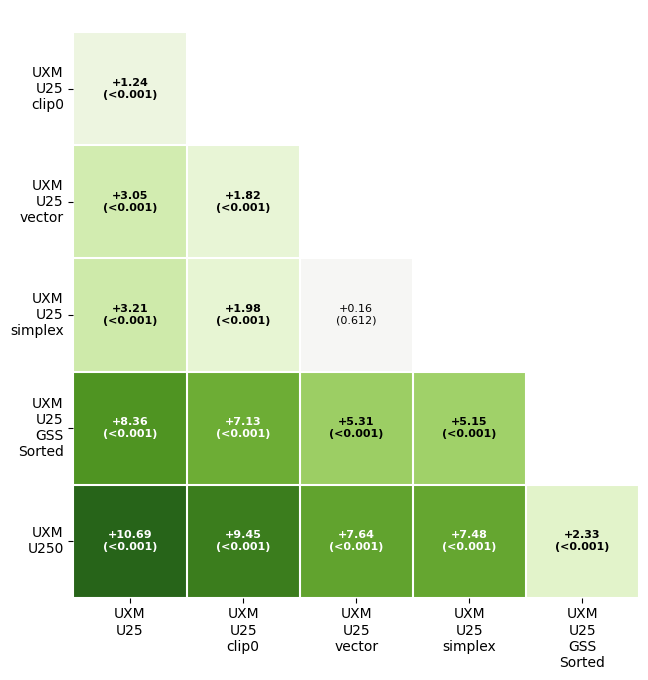

In [98]:
pairwise_difference_heatmap(
    uxm_tsc,
    [
        "UXM U25",
        "UXM U25 clip0",
        "UXM U25 vector",
        "UXM U25 simplex",
        "UXM U25 GSS Sorted",
        "UXM U250",
    ],
    test="ttest_rel",
    title=" ",
    cmap="PiYG",
    display_legend=False,
    save_path="uxm_rrbs_pvalues.pdf",
)

/tmp/ipykernel_465508/3428117266.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, order=order,


(<Axes: title={'center': ' '}, ylabel='Tissue Concordance Score'>,
              method_a            method_b       p_value annotation
 0             UXM U25       UXM U25 clip0  5.586122e-32        ***
 1             UXM U25      UXM U25 vector  4.531276e-11        ***
 2             UXM U25     UXM U25 simplex  2.451944e-46        ***
 3     UXM U25 simplex      UXM U25 vector  6.115553e-01         ns
 4             UXM U25  UXM U25 GSS Sorted  1.542172e-11        ***
 5  UXM U25 GSS Sorted            UXM U250  5.790832e-04        ***
 6     UXM U25 simplex  UXM U25 GSS Sorted  5.682001e-05        ***)

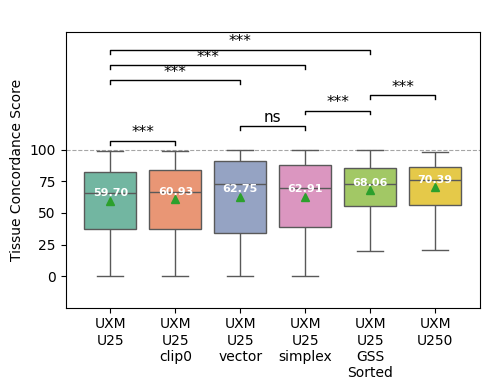

In [84]:
compare_methods_plot(
    uxm_tsc,
    uxm_tsc.columns[4:],
    show_points=False,
    # baseline='UXM U25',
    pairs=[
        ("UXM U25", "UXM U25 clip0"),
        ("UXM U25", "UXM U25 vector"),
        ("UXM U25", "UXM U25 simplex"),
        ("UXM U25 simplex", "UXM U25 vector"),
        ("UXM U25", "UXM U25 GSS Sorted"),
        # ("UXM U25", "UXM U250"),
        ("UXM U25 GSS Sorted", "UXM U250"),
        ("UXM U25 simplex", "UXM U25 GSS Sorted"),
    ],
    figsize=(5, 4),
    kind="box",
    bracket_step=0.12,
    test="ttest_rel",
    central_tendency="mean",
    show_ns=True,
    title=" ",
    ylabel="Tissue Concordance Score",
    save_path="uxm_rrbs_results.pdf",
)

/tmp/ipykernel_21463/843710896.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21463/843710896.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21463/843710896.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21463/843710896.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21463/843710896.py:197: FutureWarning

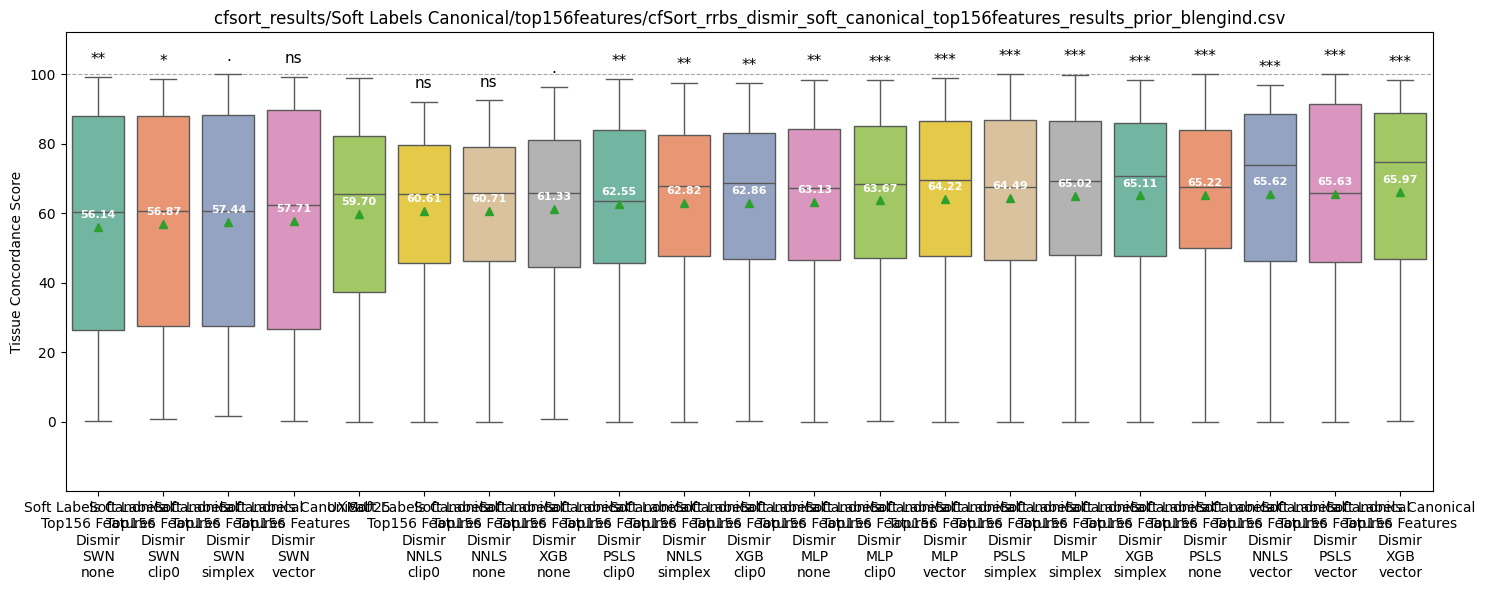

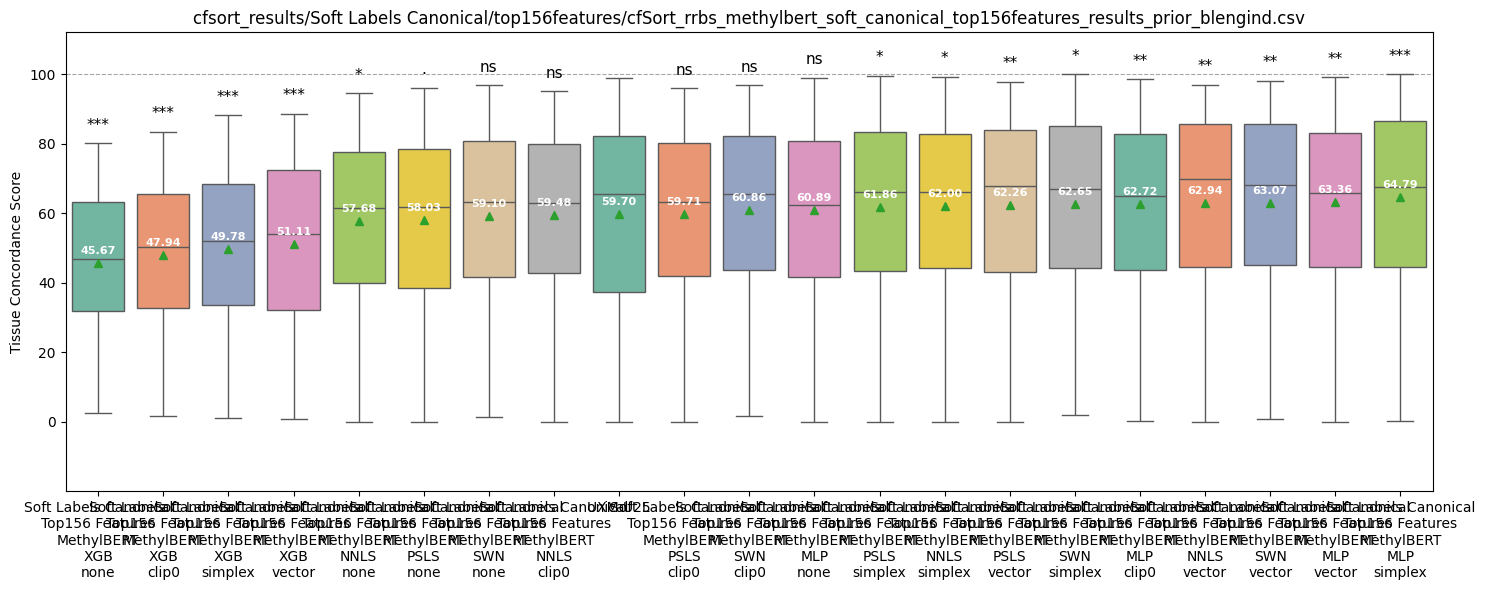

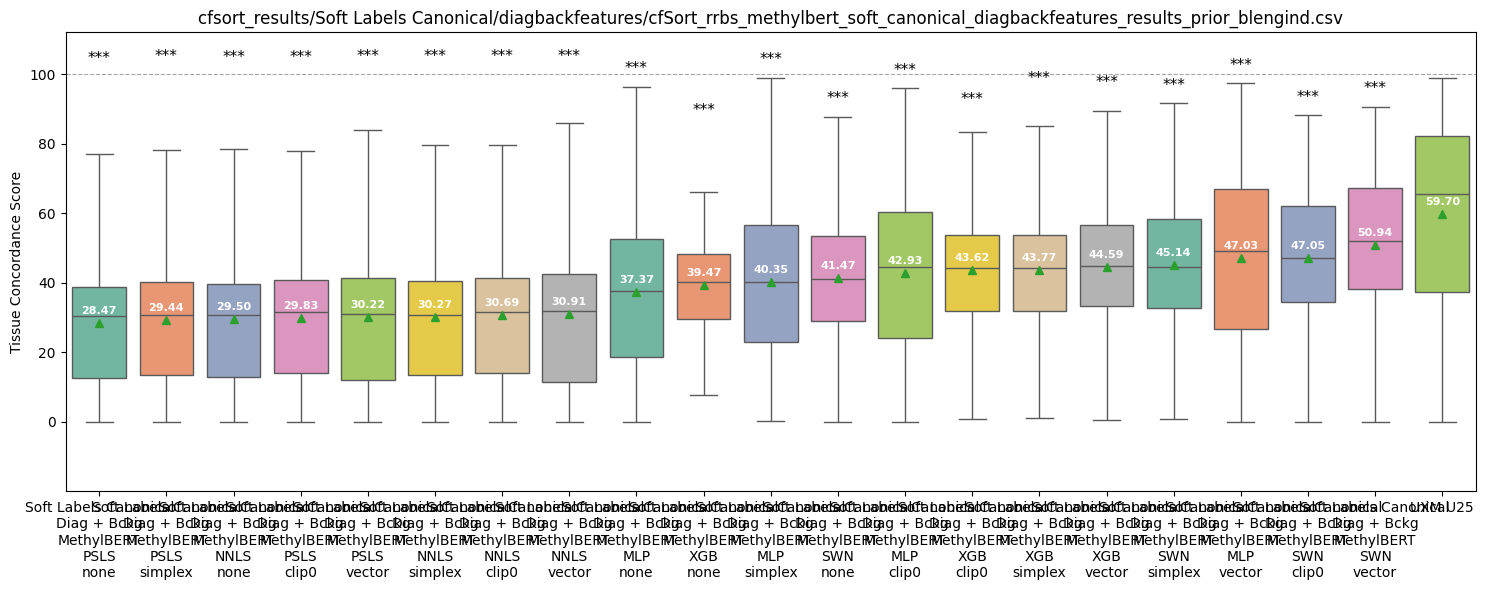

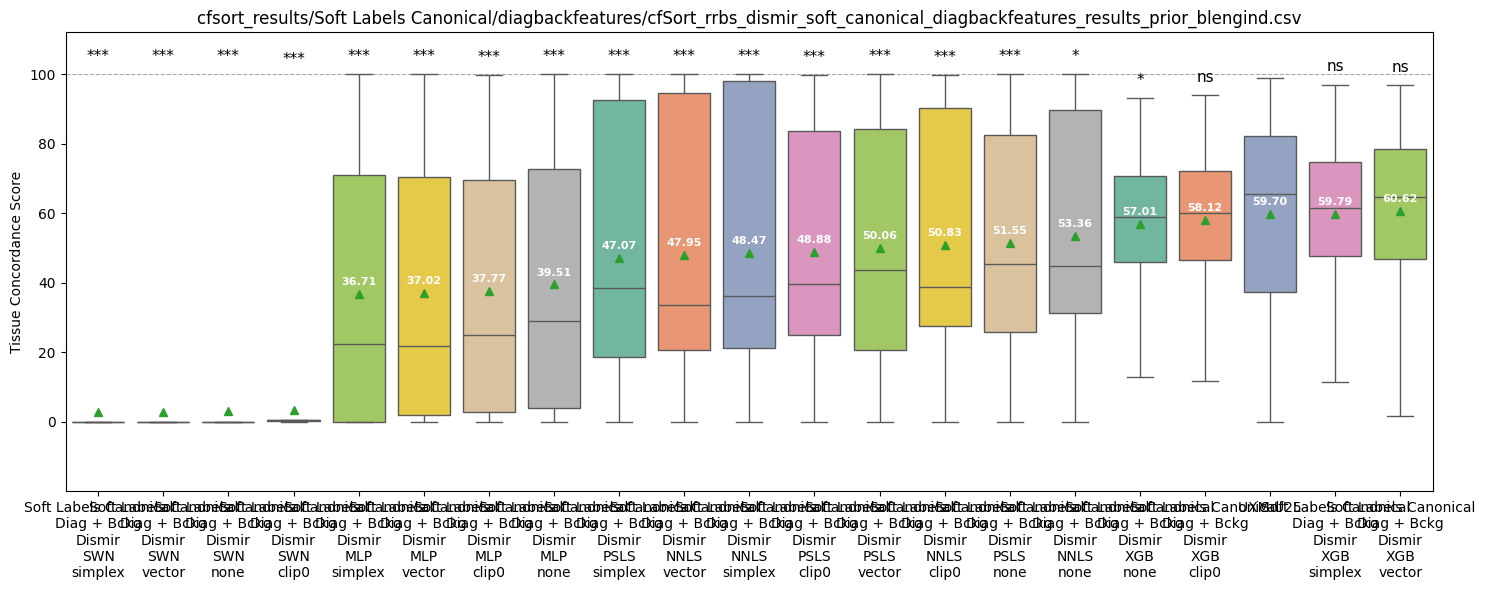

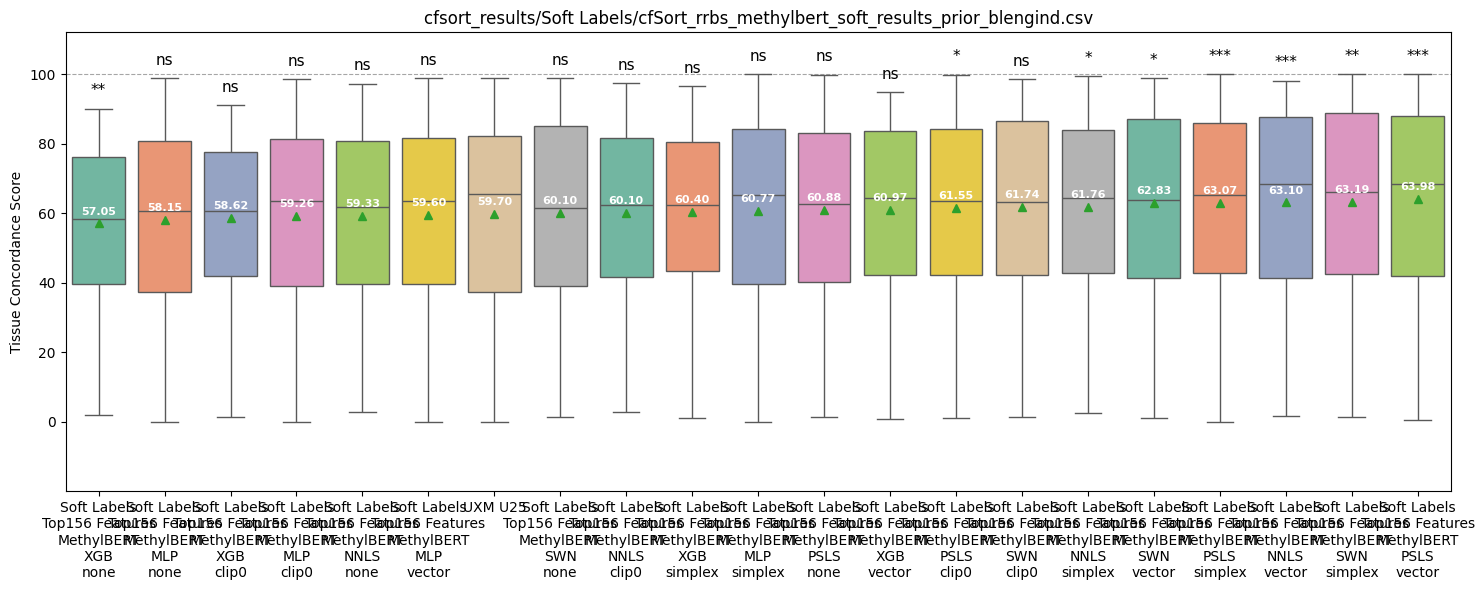

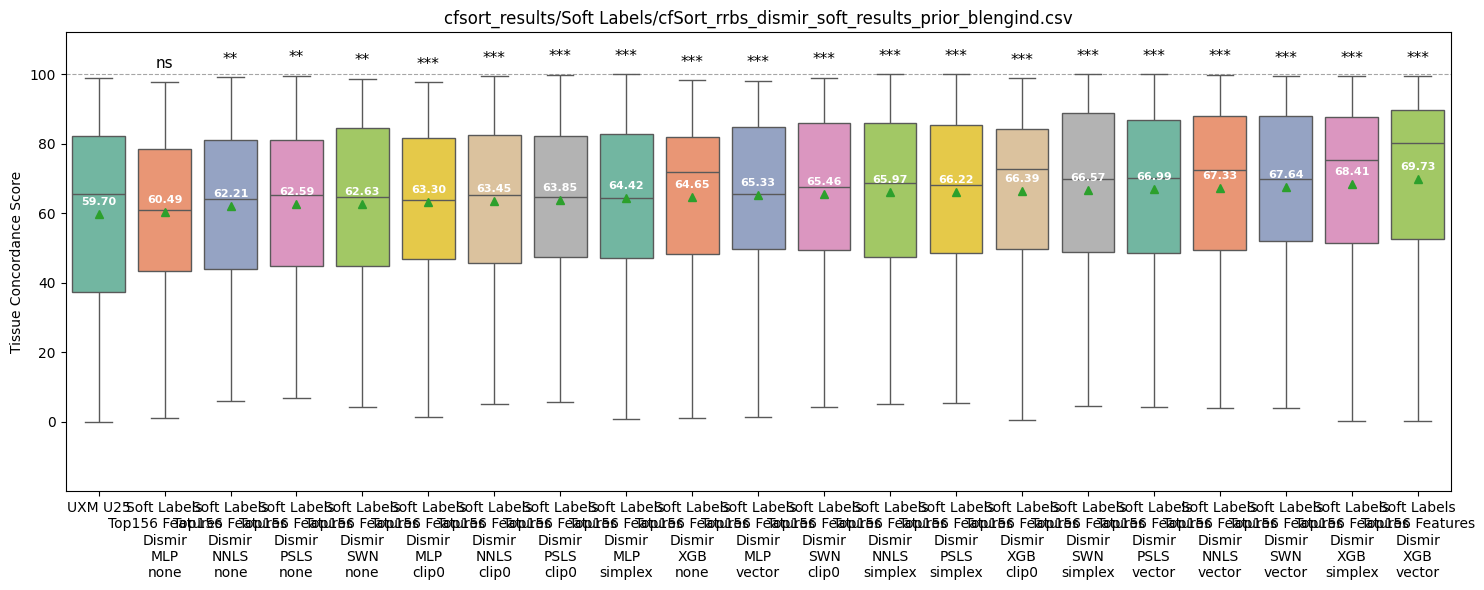

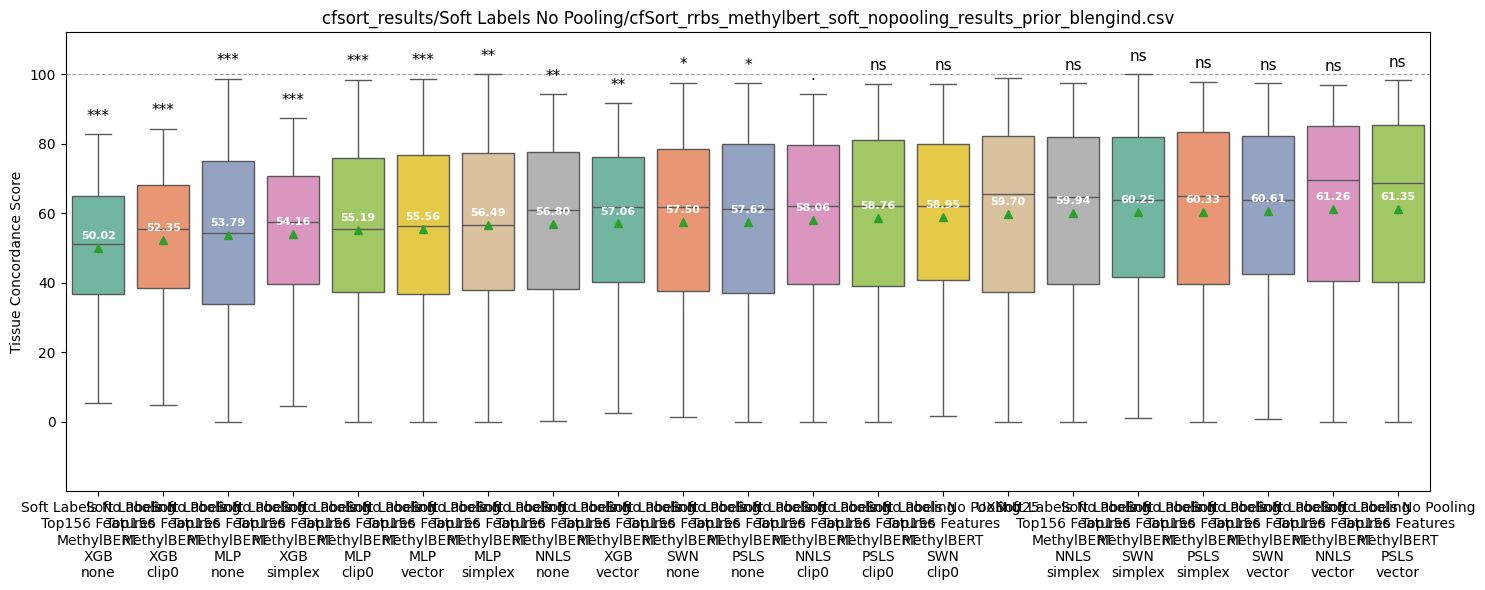

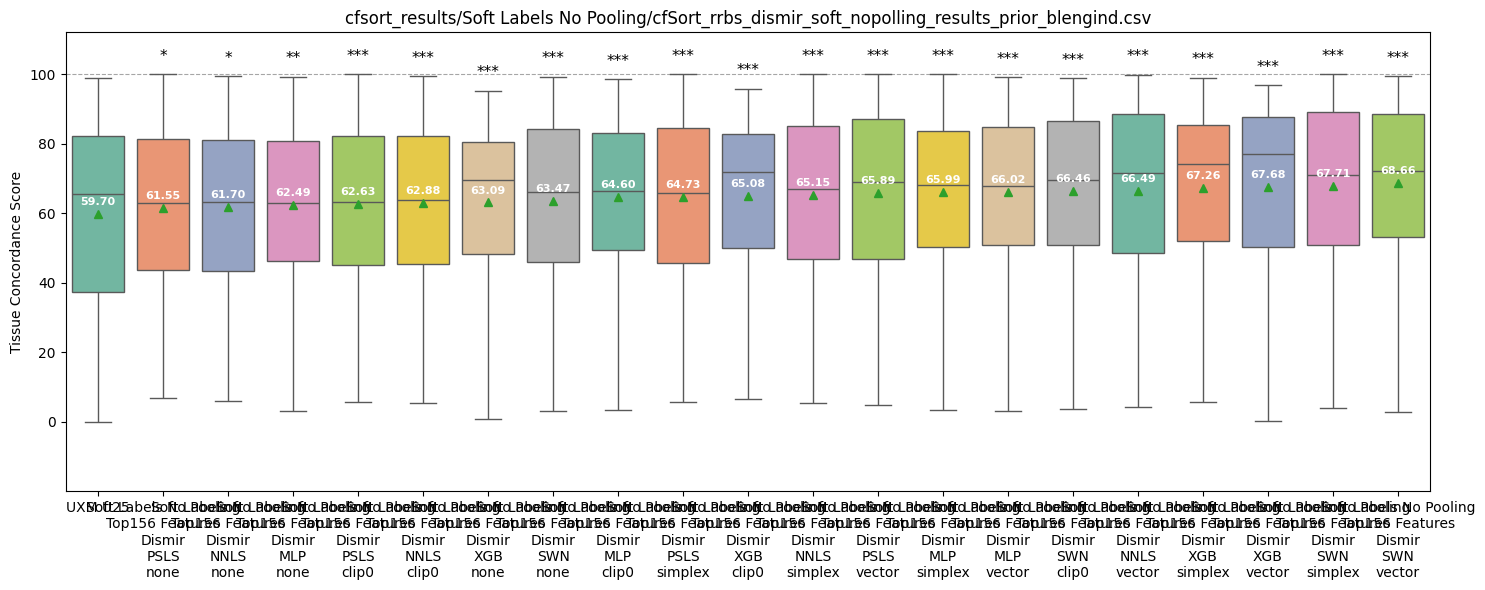

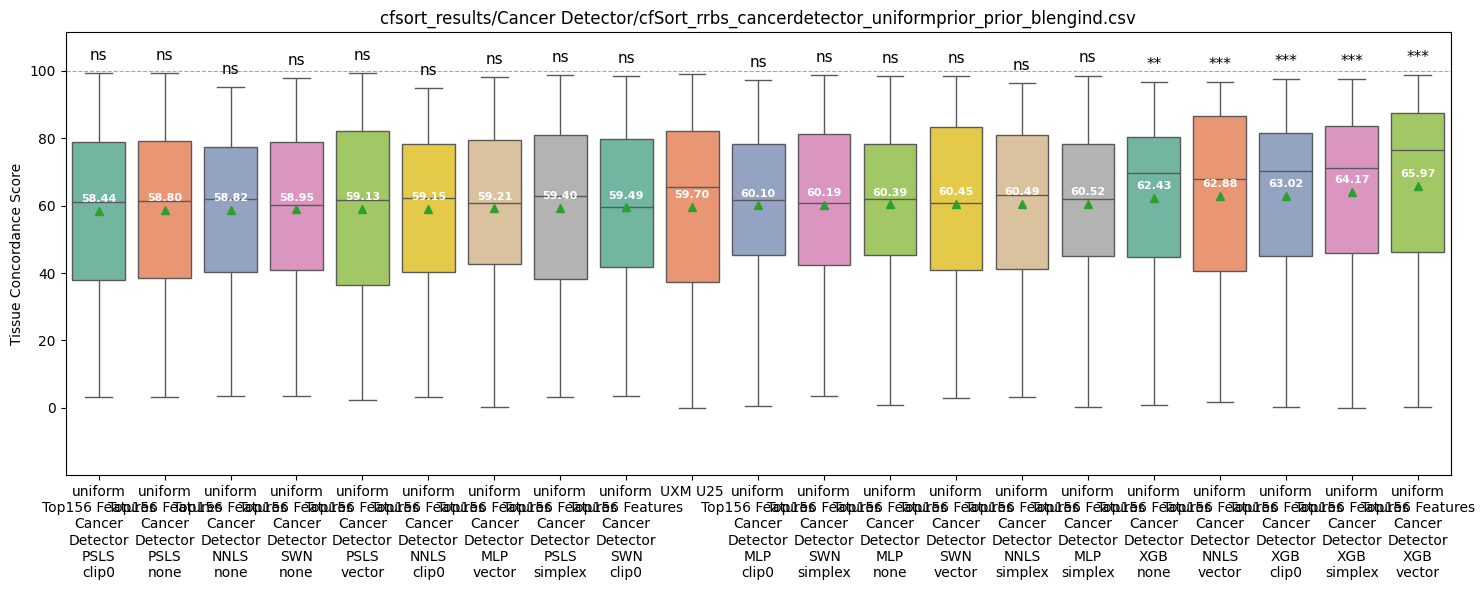

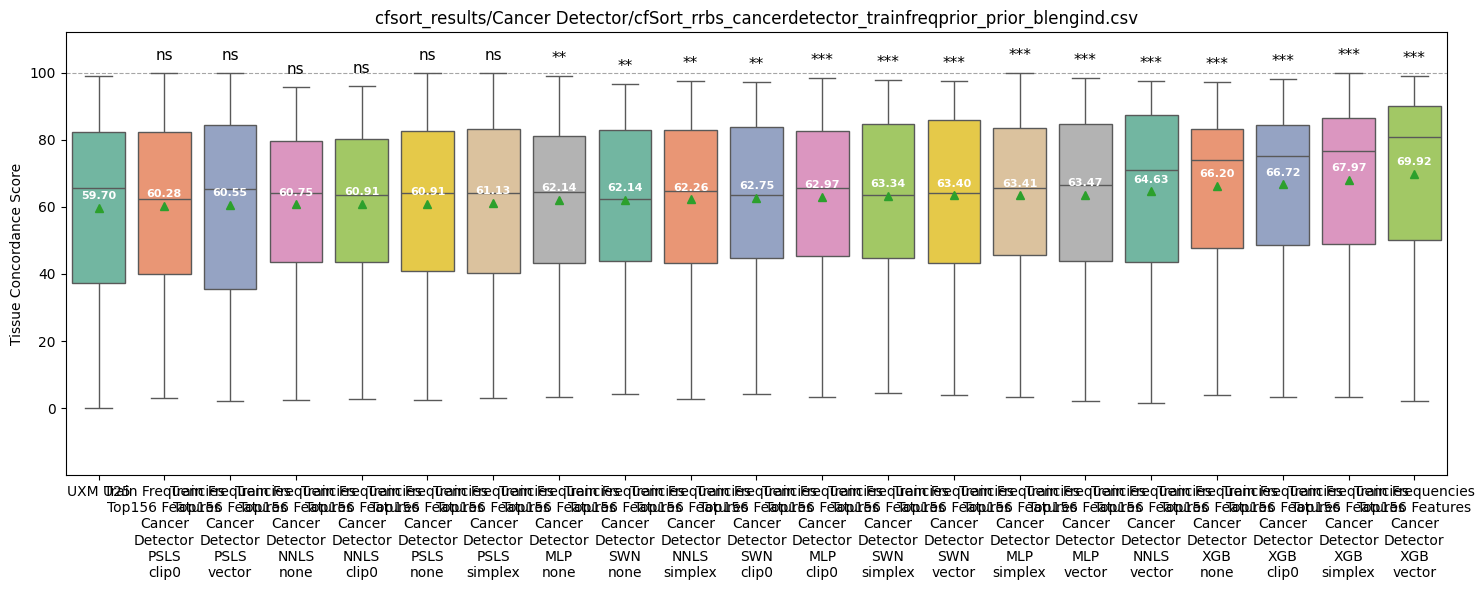

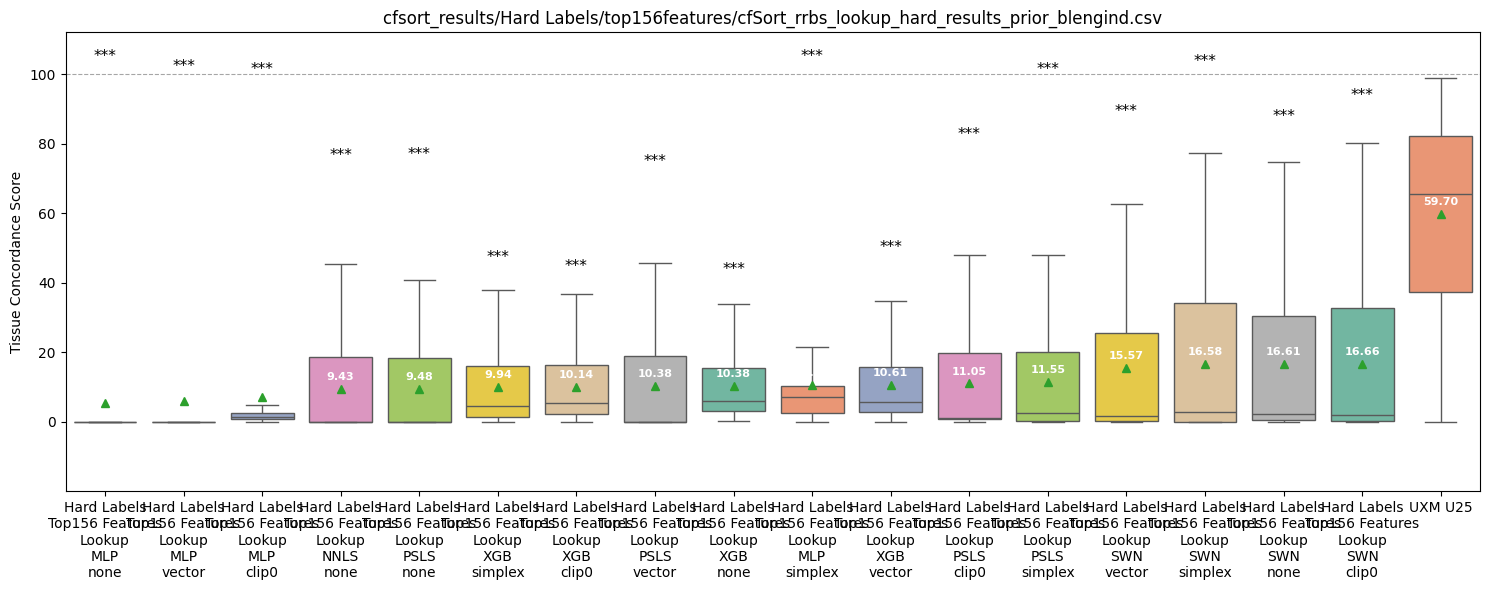

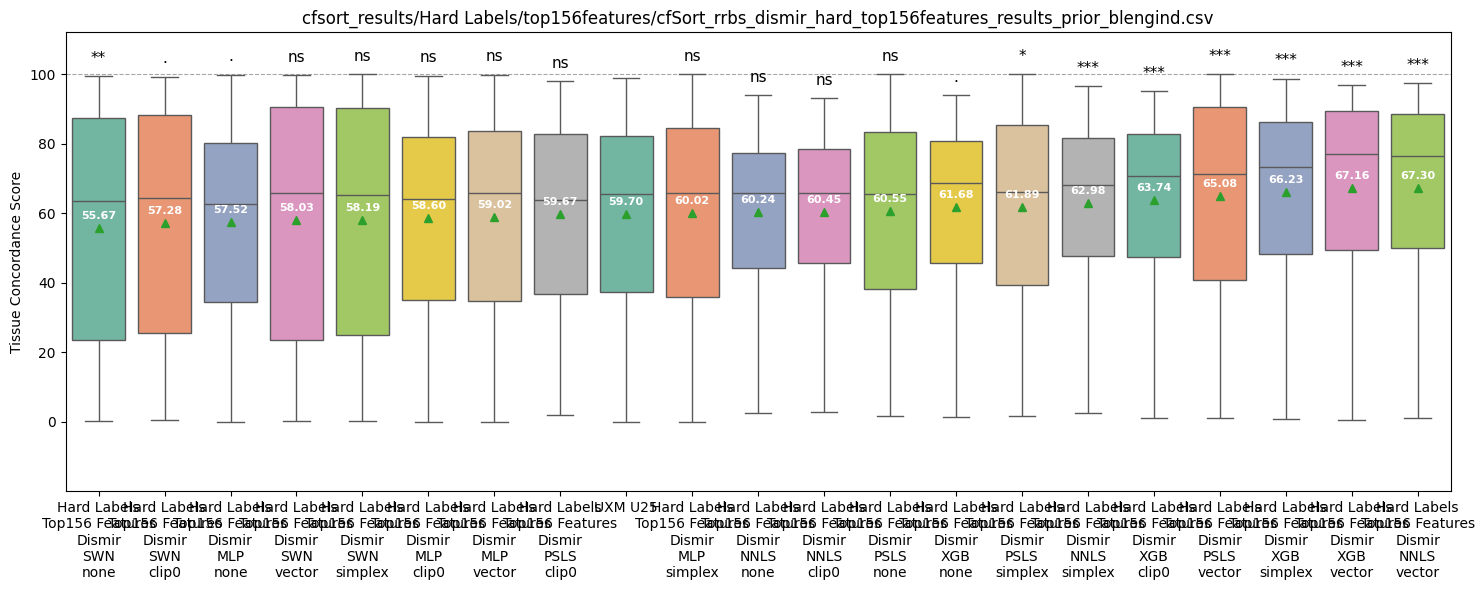

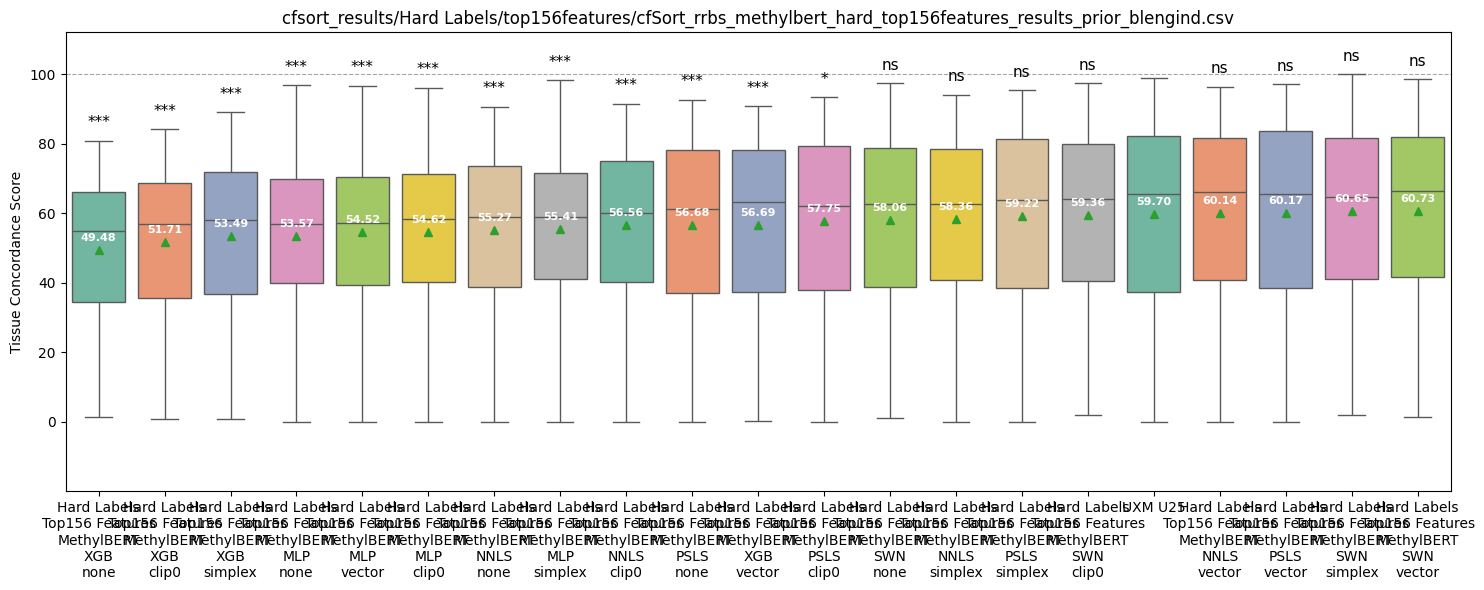

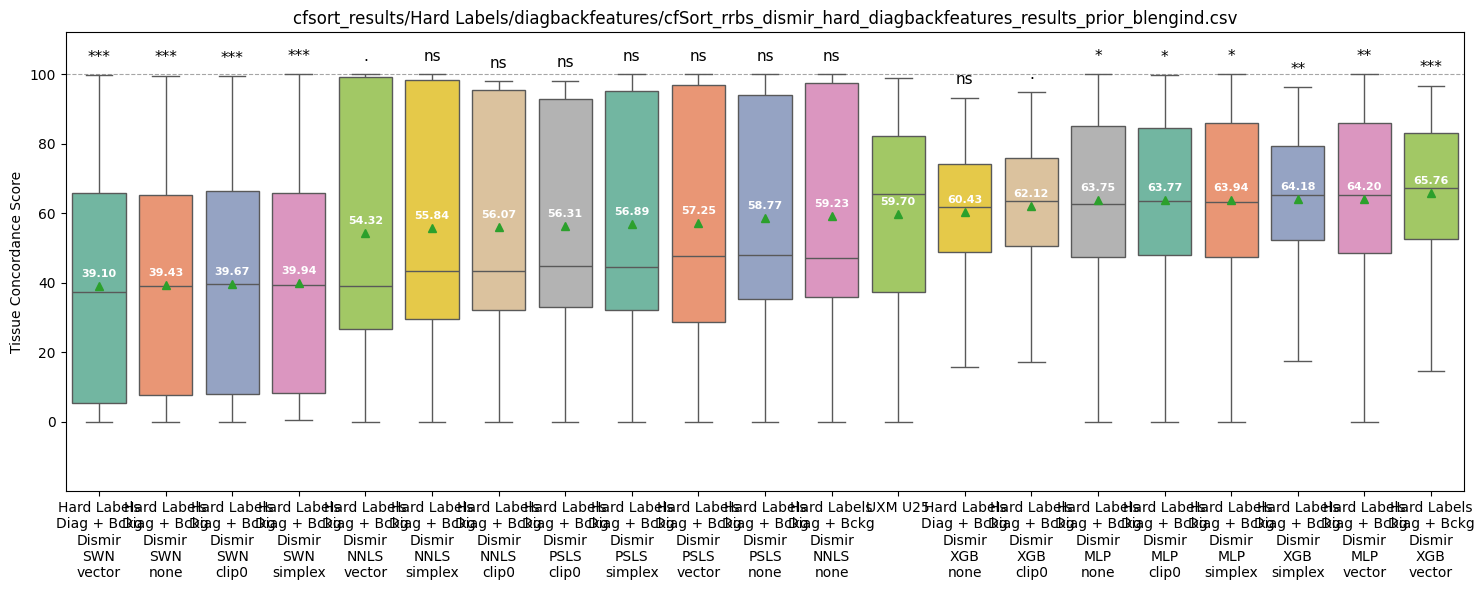

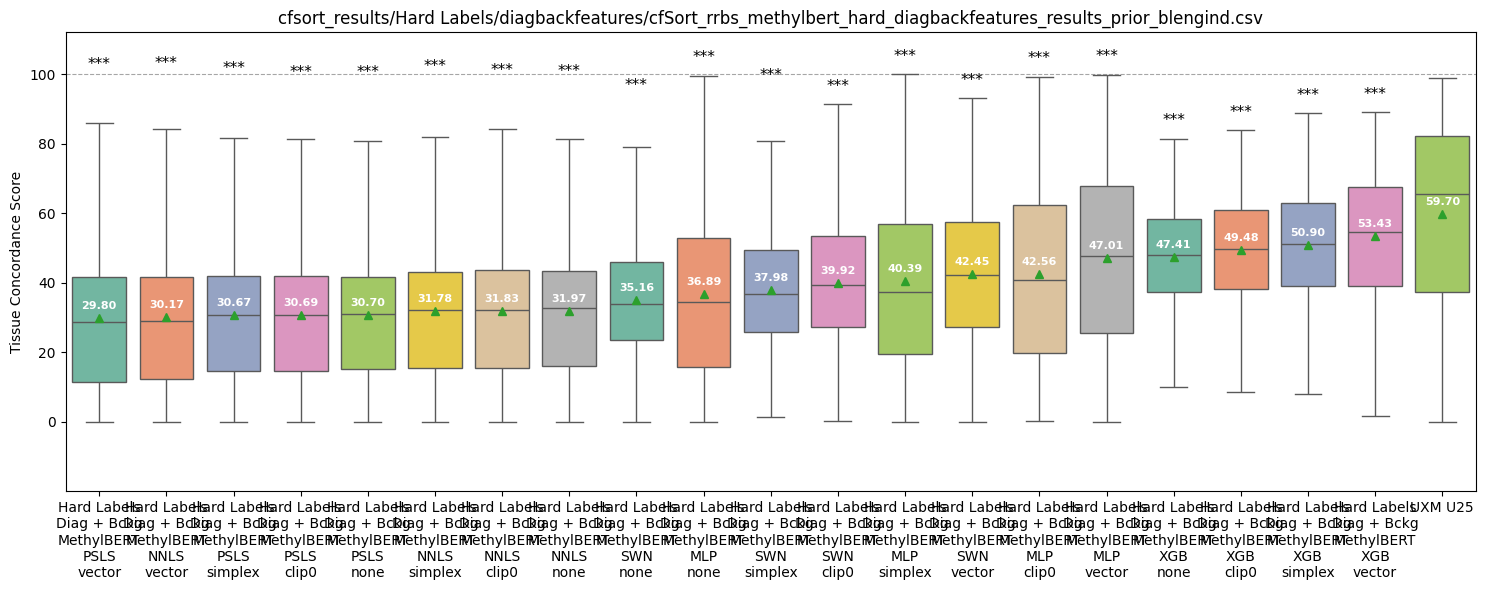

In [124]:
for i in range(1, len(files_with_results)):
    methods = our_results[i].columns[5:]
    syto_tsc = compute_on_target_proportions(
        our_results[i], tissue_mapping_df, methods
    ).dropna()
    syto_tsc = syto_tsc.merge(uxm_tsc[["file", "UXM U25"]], on="file")
    compare_methods_plot(
        syto_tsc,
        syto_tsc.columns[4:],
        show_points=False,
        baseline="UXM U25",
        figsize=(15, 6),
        kind="box",
        central_tendency="mean",
        bracket_step=0.12,
        test="ttest_rel",
        show_ns=True,
        title=f"{files_with_results[i]}",
        ylabel="Tissue Concordance Score",
        label_sep="__",
        inline_annotations=True,
        orient="v",
    )

Computing main-paper figures

In [81]:
best_results = [
    (
        "cfsort_results/Cancer Detector/cfSort_rrbs_cancerdetector_trainfreqprior_prior_blengind.csv",
        "Train Frequencies__Top156 Features__Cancer__Detector__XGB__vector",
    ),
    (
        "cfsort_results/Soft Labels Canonical/top156features/cfSort_rrbs_dismir_soft_canonical_top156features_results_prior_blengind.csv",
        "Soft Labels Canonical__Top156 Features__Dismir__XGB__vector",
    ),
    (
        "cfsort_results/Soft Labels/cfSort_rrbs_dismir_soft_results_prior_blengind.csv",
        "Soft Labels__Top156 Features__Dismir__XGB__vector",
    ),
    (
        "cfsort_results/Soft Labels No Pooling/cfSort_rrbs_dismir_soft_nopolling_results_prior_blengind.csv",
        "Soft Labels No Pooling__Top156 Features__Dismir__SWN__vector",
    ),
    (
        "cfsort_results/Hard Labels/top156features/cfSort_rrbs_dismir_hard_top156features_results_prior_blengind.csv",
        "Hard Labels__Top156 Features__Dismir__NNLS__vector",
    ),
]

In [78]:
from tqdm import tqdm

In [82]:
main_tsc = uxm_tsc.copy(True)

for file, method in tqdm(best_results):
    target = [i for (i, x) in enumerate(files_with_results) if x == file][0]
    syto_tsc = compute_on_target_proportions(
        our_results[target], tissue_mapping_df, our_results[target].columns[5:]
    ).dropna()
    main_tsc = main_tsc.merge(syto_tsc[["file", method]], on="file")

100%|██████████| 5/5 [00:04<00:00,  1.05it/s]


In [38]:
# compare_methods_plot(
#     main_tsc,
#     ['UXM U25', 'UXM U250',
#        'Train Frequencies__Cancer__Detector__XGB__vector',
#        'Soft Labels Canonical__Dismir__XGB__vector',
#        'Soft Labels__Dismir__XGB__vector',
#        'Soft Labels No Pooling__Dismir__SWN__vector',
#        'Hard Labels__Dismir__NNLS__vector'],
#     show_points=False,
#     baseline='UXM U25',
#     # pairs = [
#     #     ("UXM U25", "UXM U250"),
#     #     ("UXM U25", "UXM U25 vector"),
#     #     ("UXM U25", "UXM U25 simplex"),
#     #     ("UXM U25 simplex", "UXM U25 vector"),
#     #     ("UXM U25", "UXM U25 GSS Sorted"),
#     #     # ("UXM U25", "UXM U250"),
#     #     ("UXM U25 GSS Sorted", "UXM U250"),
#     #     ("UXM U25 simplex", "UXM U25 GSS Sorted"),
#     #     ],
#     figsize=(8,6),
#     orient = "h",
#     inline_annotations=True,
#     kind="box",
#     label_sep="__",
#     bracket_step=0.12,
#     test="ttest_rel",
#     show_ns=True, title=" ",
#     central_tendency = "mean",
#     ylabel = "Tissue Concordance Score",
#     save_path = "main_rrbs_results_h.pdf")

In [83]:
main_tsc_forcd = main_tsc.copy(True)

In [ ]:
# main_tsc.rename(
#     columns={
#         'Soft Labels Canonical__Dismir__XGB__vector': 'Canonical__Soft Labels__Dismir__XGB__vector',
#         'Hard Labels__Dismir__NNLS__vector':'Hard Labels__w/ bckg.__Dismir__NNLS__vector',
#         'Soft Labels No Pooling__Dismir__SWN__vector': 'DD Soft Lb-s__w/o pool.__Dismir__SWN__vector',
#         'Soft Labels__Dismir__XGB__vector': 'DD Soft Lb-s__w/ pool.__Dismir__XGB__vector',
#         'Train Frequencies__Cancer__Detector__XGB__vector':'Training__Counts__Cancer__Detector__XGB__vector'
#     },
#     inplace=True
# )

In [84]:
main_tsc_forcd.rename(
    columns={
        "UXM U25": "UXM__U25",
        "Soft Labels Canonical__Top156 Features__Dismir__XGB__vector": "Canonical__SL",
        "Hard Labels__Top156 Features__Dismir__NNLS__vector": "HL__w/ bckg",
        "Soft Labels No Pooling__Top156 Features__Dismir__SWN__vector": "DD SL__w/o pool",
        "Soft Labels__Top156 Features__Dismir__XGB__vector": "DD SL__w/ pool",
        "Train Frequencies__Top156 Features__Cancer__Detector__XGB__vector": "Cancer__Detector",
        "UXM U250": "UXM__U250",
    },
    inplace=True,
)

(<Axes: title={'center': 'Critical-difference diagram (Nemenyi, α=0.05)'}, xlabel='Average rank (1 = best)'>,
 UXM U25            6.1875
 Canonical SL       4.6250
 HL w/ bckg         4.1250
 DD SL w/o pool     3.8750
 DD SL w/ pool      2.7500
 UXM U250           3.6875
 Cancer Detector    2.7500
 dtype: float64,
 {'cd': np.float64(2.251816608880544),
  'friedman_p': np.float64(6.349646189034818e-05),
  'cliques': [(0, 5), (4, 6)],
  'nonsig': array([[ True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True],
         [ True,  True,  True,  True,  True,  True,  True],
         [False,  True,  True,  True,  True,  True,  True],
         [False,  True,  True,  True,  True,  True,  True],
         [False,  True,  True,  True,  True,  True,  True],
         [False,  True,  True,  True,  True,  True,  True]]),
  'avg_ranks': UXM U25            6.1875
  Canonical SL       4.6250
  HL w/ bckg         4.1250
  DD SL w/o pool     3.8750
  DD S

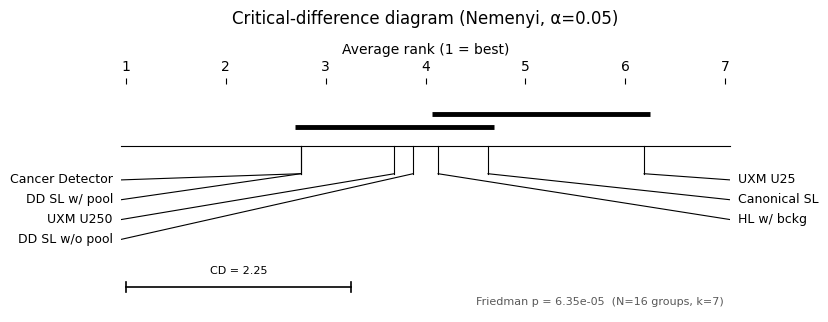

In [42]:
cd_diagram(
    df=main_tsc_forcd,
    methods=[
        "UXM U25",
        "Canonical SL",
        "HL w/ bckg",
        "DD SL w/o pool",
        "DD SL w/ pool",
        "UXM U250",
        "Cancer Detector",
    ],
    aggregate_by="Biosample term name",
    alpha=0.05,
)

In [265]:
main_tsc_forcd_aggregated = (
    main_tsc_forcd[
        [
            "Biosample term name",
            "UXM__U25",
            "UXM U25 clip0",
            "UXM U25 simplex",
            "UXM U25 vector",
            "UXM__U250",
            "UXM U25 GSS Sorted",
            "Cancer__Detector",
            "Canonical__SL",
            "DD SL__w/ pool",
            "DD SL__w/o pool",
            "HL__w/ bckg",
        ]
    ]
    .groupby("Biosample term name")
    .aggregate("mean")
)

In [274]:
main_tsc_forcd_aggregated.reset_index(inplace=True)

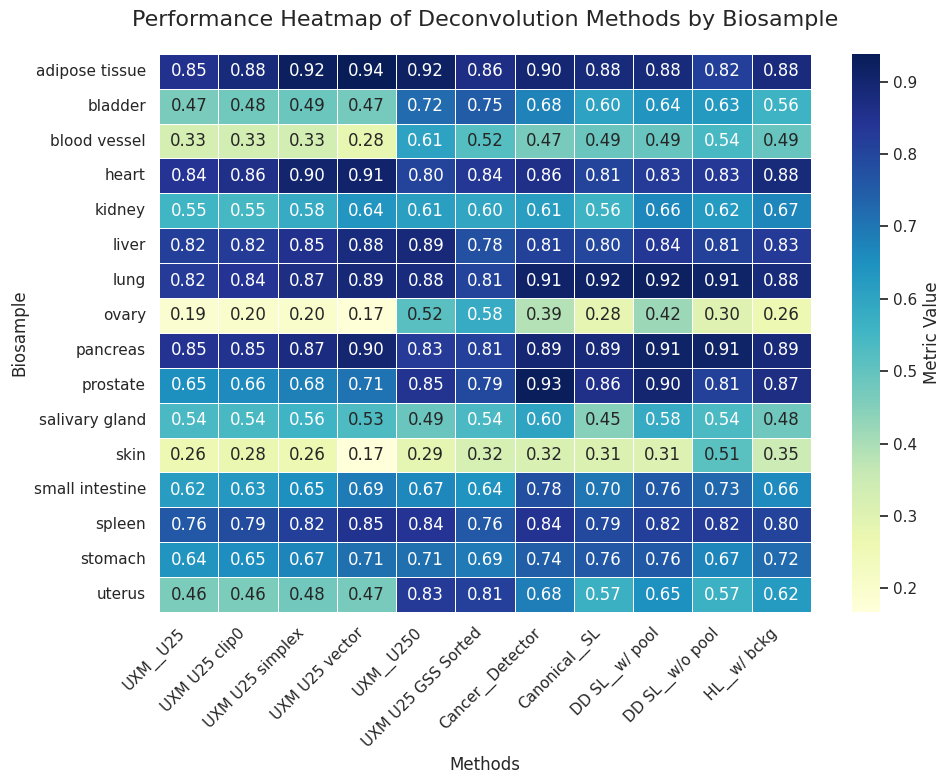

In [285]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def plot_deconvolution_heatmap(df, index="Biosample term name"):
    """
    Creates a heatmap using 'Biosample term name' as rows
    and deconvolution methods (columns 1 to 11) as columns.
    """
    # 1. Set the Biosample name as the index to serve as the y-axis labels
    # We use column 0 as the index
    plot_data = df.set_index(index)

    # 2. Ensure only the deconvolution method columns are selected
    # (Indexes 1 to 11 of the original dataframe)
    # Since we set index, we just take all remaining columns

    # 3. Handle potential non-numeric data
    plot_data = plot_data.apply(pd.to_numeric, errors="coerce")

    # 4. Set up the figure size
    plt.figure(figsize=(10, 8))

    # 5. Create the heatmap
    sns.heatmap(
        plot_data,
        annot=True,  # Display the values inside the cells
        fmt=".2f",  # Use 2 decimal places
        cmap="YlGnBu",  # Yellow-Green-Blue gradient (lighter = lower, darker = higher)
        linewidths=0.5,  # Add thin lines between cells for clarity
        cbar_kws={"label": "Metric Value"},
    )

    # 6. Formatting
    plt.title(
        "Performance Heatmap of Deconvolution Methods by Biosample", fontsize=16, pad=20
    )
    plt.xlabel("Methods", fontsize=12)
    plt.ylabel("Biosample", fontsize=12)
    plt.xticks(rotation=45, ha="right")  # Rotate method names for better fit

    plt.tight_layout()
    plt.show()


# Execution
plot_deconvolution_heatmap(main_tsc_forcd_aggregated)

# plot_deconvolution_heatmap(main_tsc_forcd[main_tsc_forcd["Biosample term name"]=="skin"][['file', 'UXM__U25', 'UXM U25 clip0', 'UXM U25 simplex',
#        'UXM U25 vector', 'UXM__U250', 'UXM U25 GSS Sorted', 'Cancer__Detector',
#        'Canonical__SL', 'DD SL__w/ pool', 'DD SL__w/o pool', 'HL__w/ bckg']], index="file")

(<Axes: title={'center': ' '}>,
                    UXM__U25  Canonical__SL  HL__w/ bckg  DD SL__w/o pool  \
 UXM__U25                NaN      -6.275346    -7.602731        -8.965500   
 Canonical__SL      6.275346            NaN    -1.327385        -2.690154   
 HL__w/ bckg        7.602731       1.327385          NaN        -1.362769   
 DD SL__w/o pool    8.965500       2.690154     1.362769              NaN   
 DD SL__w/ pool    10.034462       3.759115     2.431731         1.068962   
 Cancer__Detector  10.218269       3.942923     2.615538         1.252769   
 UXM__U250         10.689346       4.414000     3.086615         1.723846   
 
                   DD SL__w/ pool  Cancer__Detector  UXM__U250  
 UXM__U25              -10.034462        -10.218269 -10.689346  
 Canonical__SL          -3.759115         -3.942923  -4.414000  
 HL__w/ bckg            -2.431731         -2.615538  -3.086615  
 DD SL__w/o pool        -1.068962         -1.252769  -1.723846  
 DD SL__w/ pool          

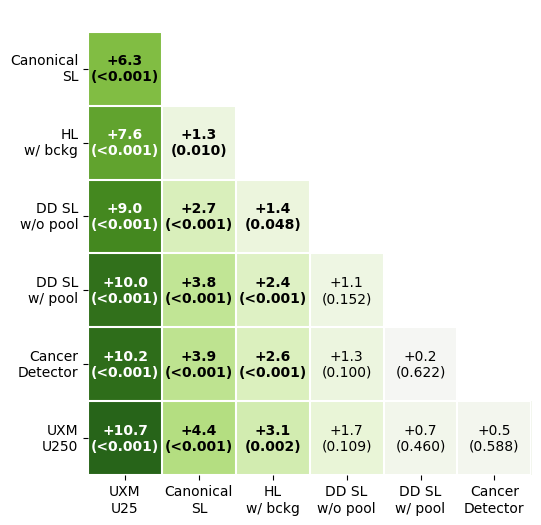

In [96]:
pairwise_difference_heatmap(
    main_tsc_forcd,
    [
        "UXM__U25",
        "Canonical__SL",
        "HL__w/ bckg",
        "DD SL__w/o pool",
        "DD SL__w/ pool",
        "Cancer__Detector",
        "UXM__U250",
    ],
    test="ttest_rel",
    title=" ",
    cmap="PiYG",
    save_path="main_rrbs_pvalues_numbers.pdf",
    figsize=(5.5, 5.5),
    label_sep="__",
    pvalue_decimals=3,
    diff_decimals=1,
    cell_fontsize=10,
    annotation_format="pvalue",
    display_legend=False,
)

### Analysis of aggregated rrbs matrices

In [4]:
import os
import pickle

In [ ]:
deconvolutions_path = "/data/dmytro/Experiments/cfsort_rrbs/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_d041_postfiltered_min_length_50_soft_labels_pooled_jakkard/pseudobulk/deconvolutions/"

In [8]:
import os
import pickle
import pandas as pd
from pathlib import Path


def aggregate_low_coverage_dmrs(
    deconvolutions_path,
    thresholds=(0, 5, 10, 30),
    inner_filename="dmr_aggregated.pkl",
    label_col="dmr_ctype_label",
    reads_col="n_reads",
    verbose=True,
):
    """
    For each per-file deconvolution result, identify DMR cell-type labels whose
    n_reads falls below each given threshold, count them, and collect the labels.

    Parameters
    ----------
    deconvolutions_path : str or Path
        Directory whose immediate subdirectories each contain `inner_filename`.
    thresholds : tuple of int
        Read-count thresholds. The first one is treated as exact equality
        (n_reads == 0); the rest as strict inequalities (n_reads < t).
        Adjust the rule below if you want a different convention.
    inner_filename : str
        Name of the pickle file inside each subdirectory.
    label_col, reads_col : str
        Column names in the loaded dataframe.
    verbose : bool
        Print a warning for files that fail to load or are missing columns.

    Returns
    -------
    pd.DataFrame
        One row per file with columns:
            file_name,
            count_eq_0, count_lt_5, count_lt_10, count_lt_30,
            labels_eq_0, labels_lt_5, labels_lt_10, labels_lt_30
        (column names follow the thresholds you pass in)
    """
    deconvolutions_path = Path(deconvolutions_path)

    # Build (column_suffix, predicate) for each threshold.
    # First threshold uses ==, others use <.
    rules = []
    for i, t in enumerate(thresholds):
        if i == 0:
            rules.append((f"eq_{t}", lambda s, t=t: s == t))
        else:
            rules.append((f"lt_{t}", lambda s, t=t: s < t))

    rows = []
    subdirs = sorted(p for p in deconvolutions_path.iterdir() if p.is_dir())

    for subdir in subdirs:
        pkl_path = subdir / inner_filename
        if not pkl_path.exists():
            if verbose:
                print(f"[skip] {subdir.name}: {inner_filename} not found")
            continue

        try:
            with open(pkl_path, "rb") as f:
                df = pickle.load(f)
        except Exception as e:
            if verbose:
                print(f"[skip] {subdir.name}: failed to load ({e})")
            continue

        if not isinstance(df, pd.DataFrame):
            if verbose:
                print(
                    f"[skip] {subdir.name}: pickle is {type(df).__name__}, not DataFrame"
                )
            continue
        if label_col not in df.columns or reads_col not in df.columns:
            if verbose:
                print(f"[skip] {subdir.name}: missing required columns")
            continue

        row = {"file_name": subdir.name}
        for suffix, predicate in rules:
            mask = predicate(df[reads_col])
            labels = df.loc[mask, label_col].tolist()
            row[f"count_{suffix}"] = int(mask.sum())
            row[f"labels_{suffix}"] = labels
        rows.append(row)

    # Preserve a sensible column order
    count_cols = [f"count_{suffix}" for suffix, _ in rules]
    label_cols = [f"labels_{suffix}" for suffix, _ in rules]
    result = pd.DataFrame(rows, columns=["file_name"] + count_cols + label_cols)
    return result

In [9]:
aggregated_stats = aggregate_low_coverage_dmrs(
    deconvolutions_path,
    thresholds=(0, 5, 10, 30),
    inner_filename="dmr_aggregated.pkl",
    label_col="dmr_ctype_label",
    reads_col="n_reads",
    verbose=True,
)

In [26]:
aggregated_stats["file_name"] = aggregated_stats["file_name"].apply(
    lambda x: x.split("_")[0]
)

In [32]:
aggregated_stats

,file_name,count_eq_0,count_lt_5,count_lt_10,count_lt_30,labels_eq_0,labels_lt_5,labels_lt_10,labels_lt_30
0,GSM7427236,3,4,4,7,"[11, 16, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 9, 11, 15, 16, 19, 37]"
1,GSM7427237,2,4,4,6,"[11, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 10, 11, 15, 16, 37]"
2,GSM7427238,3,4,4,6,"[11, 16, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 11, 15, 16, 32, 37]"
3,GSM7427239,2,3,3,6,"[11, 37]","[11, 16, 37]","[11, 16, 37]","[0, 10, 11, 15, 16, 37]"
4,GSM7427240,1,2,3,5,[11],"[11, 37]","[0, 11, 37]","[0, 11, 15, 16, 37]"
...,...,...,...,...,...,...,...,...,...
516,GSM7427756,3,3,3,5,"[11, 16, 37]","[11, 16, 37]","[11, 16, 37]","[0, 11, 15, 16, 37]"
517,GSM7427757,1,2,2,3,[11],"[11, 37]","[11, 37]","[11, 16, 37]"
518,GSM7427758,2,3,3,4,"[11, 37]","[11, 16, 37]","[11, 16, 37]","[11, 15, 16, 37]"
519,GSM7427759,1,2,2,2,[11],"[11, 37]","[11, 37]","[11, 37]"


In [34]:
aggregated_stats[
    aggregated_stats["file_name"].apply(
        lambda x: x in methylbert_soft_tsc["file"].to_list()
    )
].count_lt_30.value_counts()

count_lt_30
5    142
6     96
4     17
7      3
2      1
3      1
Name: count, dtype: int64

### Correlation between tcs and various pseudobulk metrics

In [32]:
pseudobulk_metrics = pd.read_csv("pseudobulk_metrics.tsv", delimiter="\t")

In [31]:
RESULTS_PER_TISSUE = False

In [125]:
all_tsc_results = []
all_tsc_results_full = []  # NEW: collect non-aggregated melted results

for res in our_results:
    if "UXM_U25" in res.columns:
        syto_tsc = uxm_tsc
    else:
        syto_tsc = compute_on_target_proportions(
            res, tissue_mapping_df, res.columns[5:]
        ).dropna()

    syto_tsc_melted = syto_tsc.melt(
        id_vars=[
            "file",
            "Biosample term name",
            "expected_cell_types",
            "final_mapping_rate",
        ]
    )
    if RESULTS_PER_TISSUE:
        aggregated_tsc = (
            syto_tsc_melted[["variable", "Biosample term name", "value"]]
            .groupby(["Biosample term name", "variable"])
            .aggregate("mean")
            .reset_index()
        )
        aggregated_tsc = (
            aggregated_tsc[["variable", "value"]]
            .groupby("variable")
            .aggregate("mean")
            .reset_index()
        )
    else:
        aggregated_tsc = (
            syto_tsc_melted[["variable", "value"]]
            .groupby("variable")
            .aggregate("mean")
            .reset_index()
        )

    # NEW: helper that adds the metadata columns the same way for any frame
    # that contains a "variable" column.
    def _add_metadata_columns(df, is_uxm):
        df = df.copy()
        if is_uxm:
            df["Classifier"] = "UXM"
            df["Deconvolver"] = "UXM"
            df["Calibrator"] = df["variable"].apply(
                lambda x: x.split("_")[2] if len(x.split("_")) == 2 else ""
            )
            # Make sure all frames have the same set of columns so concat is clean.
            df["Prior"] = ""
            df["LabelingScheme"] = ""
            df["FeatureScheme"] = ""
        else:
            classifier = df["variable"].apply(lambda x: x.split("__")[2])
            offset = 0
            if classifier.iloc[0] == "Cancer":
                df["Classifier"] = "Cancer Detector"
                offset = 1
                df["Prior"] = df["variable"].apply(lambda x: x.split("__")[0])
                df["LabelingScheme"] = ""
            else:
                df["Classifier"] = classifier
                df["Prior"] = ""
                df["LabelingScheme"] = df["variable"].apply(lambda x: x.split("__")[0])
            df["FeatureScheme"] = df["variable"].apply(lambda x: x.split("__")[1])
            df["Deconvolver"] = df["variable"].apply(
                lambda x: x.split("__")[3 + offset]
            )
            df["Calibrator"] = df["variable"].apply(lambda x: x.split("__")[4 + offset])
        return df

    is_uxm = "UXM_U25" in res.columns
    aggregated_tsc = _add_metadata_columns(aggregated_tsc, is_uxm)
    full_tsc = _add_metadata_columns(syto_tsc_melted, is_uxm)  # NEW

    all_tsc_results.append(aggregated_tsc)
    all_tsc_results_full.append(full_tsc)  # NEW


all_tsc_results = pd.concat(all_tsc_results, axis=0)
all_tsc_results_full = pd.concat(all_tsc_results_full, axis=0)  # NEW

tsc_to_pseudobulk_mapping_classifiers = {
    "UXM": "UXM",
    "Cancer Detector": "CancerDetector",
    "Dismir": "Dismir",
    "MethylBERT": "MethylBERT",
    "Lookup": "Lookup Classifier",
}

tsc_to_pseudobulk_mapping_calibrators = {
    "": np.nan,
    "none": np.nan,
    "clip0": "Lin. clip+norm",
    "simplex": "Lin. simplex",
    "vector": "Vec. scaling",
}

tsc_to_pseudobulk_mapping_prior = {
    "Train Frequencies": "Training Counts",
    "uniform": "Uniform",
    np.nan: np.nan,
    "": np.nan,
}

tsc_to_pseudobulk_mapping_labeling = {
    np.nan: np.nan,
    "": np.nan,
    "Soft Labels Canonical": "Canonical Soft Labels",
    "Soft Labels": "Data-Driven Soft-Labels (with pooling)",
    "Soft Labels No Pooling": "Data-Driven Soft-Labels (without pooling)",
    "Hard Labels": "Hard Labels",
}

tsc_to_pseudobulk_mapping_features = {
    np.nan: np.nan,
    "": np.nan,
    "Top156 Features": "Top 10%",
    "Diag + Bckg": "Diag. + Bckg.",
}


def _apply_pseudobulk_mappings(df):  # NEW
    df = df.copy()
    df["Classifier"] = df["Classifier"].apply(
        lambda x: tsc_to_pseudobulk_mapping_classifiers.get(x)
    )
    df["Calibrator"] = df["Calibrator"].apply(
        lambda x: tsc_to_pseudobulk_mapping_calibrators.get(x)
    )
    df["Prior"] = df["Prior"].apply(lambda x: tsc_to_pseudobulk_mapping_prior.get(x))
    df["LabelingScheme"] = df["LabelingScheme"].apply(
        lambda x: tsc_to_pseudobulk_mapping_labeling.get(x)
    )
    df["FeatureScheme"] = df["FeatureScheme"].apply(
        lambda x: tsc_to_pseudobulk_mapping_features.get(x)
    )
    return df


all_tsc_results = _apply_pseudobulk_mappings(all_tsc_results)
all_tsc_results_full = _apply_pseudobulk_mappings(all_tsc_results_full)  # NEW

_rename_map = {
    "LabelingScheme": "Labeling Scheme",
    "FeatureScheme": "Feature Scheme",
    "value": "TCS",
}
all_tsc_results.rename(columns=_rename_map, inplace=True)
all_tsc_results_full.rename(columns=_rename_map, inplace=True)  # NEW

all_tsc_results.reset_index(inplace=True)
all_tsc_results_full.reset_index(inplace=True)

In [126]:
def build_tcs_comparison_tables(
    df,
    deconvolvers,
    calibrators,
    target,
    feature_schemes=None,
    labeling_schemes=None,
    priors=None,
    classifiers=None,
    test="wilcoxon",
    correction=None,
    score_col="TCS",
    sample_id_cols=("file", "Biosample term name"),
):
    """
    Build (mean, std, pvalue) tables from a long-format TCS dataframe.

    Rows: (Deconvolver, Calibrator) pairs from the user-supplied lists.
    Cols: cartesian product of the column-axis fields you supply
          (Feature Scheme, Labeling Scheme, Prior, Classifier). Any of
          those passed as None are collapsed (averaged over).

    Each cell holds the mean / std / p-value of `score_col` over samples.
    The p-value is computed pairwise against `target`, which is a
    fully-specified external method given as a dict, e.g.

        target = {"Deconvolver": "UXM", "Classifier": "UXM",
                  "Calibrator": np.nan,
                  "variable": "UXM U25"}    # optional extra constraints

    Any field not in the dict is treated as "don't care". The target rows
    are pulled from `df` independently of the row/column filters and
    aggregated per sample (mean over remaining within-target rows) before
    the paired test.

    Parameters
    ----------
    df : DataFrame
        Long-format frame.
    deconvolvers, calibrators : list
        Row axis. NaN is allowed and matched correctly.
    target : dict
        Field -> value mapping that selects the reference method's rows
        from `df`. Use np.nan for fields that should match NaN.
    feature_schemes, labeling_schemes, priors, classifiers : list or None
        Column-axis filters. None means collapse that axis.
    test, correction : passed to `pairwise_pvalue_matrix`.
    score_col : str
    sample_id_cols : tuple
        Columns identifying a sample (used for the paired pivot).

    Returns
    -------
    mean_df, std_df, pval_df
    """
    from itertools import product

    # --- helpers ---------------------------------------------------------
    def _isin_with_nan(series, values):
        """Like Series.isin but treats np.nan in `values` as matching NaN."""
        values = list(values)
        has_nan = any(isinstance(v, float) and np.isnan(v) for v in values)
        non_nan = [v for v in values if not (isinstance(v, float) and np.isnan(v))]
        mask = series.isin(non_nan)
        if has_nan:
            mask = mask | series.isna()
        return mask

    def _eq_with_nan(series, value):
        if isinstance(value, float) and np.isnan(value):
            return series.isna()
        return series == value

    # --- 1. Active column-axis fields -----------------------------------
    col_field_specs = [
        ("Feature Scheme", feature_schemes),
        ("Labeling Scheme", labeling_schemes),
        ("Prior", priors),
        ("Classifier", classifiers),
    ]
    active_col_fields = [(f, vals) for f, vals in col_field_specs if vals is not None]
    active_col_names = [f for f, _ in active_col_fields]

    # --- 2. Filter the long frame for the table body -------------------
    sub = df.copy()
    sub = sub[_isin_with_nan(sub["Deconvolver"], deconvolvers)]
    sub = sub[_isin_with_nan(sub["Calibrator"], calibrators)]
    for field, vals in active_col_fields:
        sub = sub[_isin_with_nan(sub[field], vals)]
    if sub.empty:
        raise ValueError("No rows match the requested filters for the table body.")

    # --- 3. Row + column keys -------------------------------------------
    sub = sub.assign(
        _row_key=list(zip(sub["Deconvolver"], sub["Calibrator"])),
        _col_key=(
            list(zip(*[sub[f] for f in active_col_names]))
            if active_col_names
            else [()] * len(sub)
        ),
    )

    row_keys_all = [(d, c) for d in deconvolvers for c in calibrators]
    present_rows = {tuple(rk) for rk in sub["_row_key"]}

    def _row_in_present(rk):
        # Match treating NaN == NaN.
        for prk in present_rows:
            if all(
                (
                    isinstance(a, float)
                    and np.isnan(a)
                    and isinstance(b, float)
                    and np.isnan(b)
                )
                or a == b
                for a, b in zip(rk, prk)
            ):
                return True
        return False

    row_keys = [rk for rk in row_keys_all if _row_in_present(rk)]

    if active_col_names:
        col_value_lists = [vals for _, vals in active_col_fields]
        col_keys_all = list(product(*col_value_lists))
        present_cols = set(sub["_col_key"])
        col_keys = [ck for ck in col_keys_all if ck in present_cols]
    else:
        col_keys = [()]

    # --- 4. Resolve the target -----------------------------------------
    target_rows = df.copy()
    for field, value in target.items():
        if field not in target_rows.columns:
            raise ValueError(f"target field {field!r} is not a column in df.")
        target_rows = target_rows[_eq_with_nan(target_rows[field], value)]
    if target_rows.empty:
        raise ValueError(f"target {target} matched no rows in df.")

    # If multiple `variable` values match the target spec, collapse them
    # by averaging per sample so we end up with a single target column.
    target_per_sample = (
        target_rows.groupby(list(sample_id_cols))[score_col].mean().rename("__target__")
    )

    # --- 5. Mean and std over the table body ---------------------------
    grouped = sub.groupby(["_row_key", "_col_key"])[score_col]
    mean_long = grouped.mean()
    std_long = grouped.std()

    def _to_matrix(series):
        return (
            series.unstack("_col_key")
            .reindex(index=row_keys, columns=col_keys)
            .astype(float)
        )

    mean_df = _to_matrix(mean_long)
    std_df = _to_matrix(std_long)

    # --- 6. P-values vs the external target ----------------------------
    pval_df = pd.DataFrame(index=row_keys, columns=col_keys, dtype=float)
    sample_id_cols = list(sample_id_cols)
    TARGET_NAME = "__target__"

    def _tuples_equal(a, b):
        return all(
            (
                isinstance(x, float)
                and np.isnan(x)
                and isinstance(y, float)
                and np.isnan(y)
            )
            or x == y
            for x, y in zip(a, b)
        )

    for rk in row_keys:
        mask = sub["_row_key"].apply(lambda x, rk=rk: _tuples_equal(x, rk))
        row_sub = sub[mask]
        wide = row_sub.pivot_table(
            index=sample_id_cols,
            columns="_col_key",
            values=score_col,
            aggfunc="mean",
        )
        cols_here = [c for c in col_keys if c in wide.columns]
        if not cols_here:
            continue

        wide = wide.join(target_per_sample, how="left")
        if wide[TARGET_NAME].dropna().empty:
            continue

        name_map = {c: repr(c) for c in cols_here}
        wide_named = wide[cols_here + [TARGET_NAME]].rename(columns=name_map)
        methods = [name_map[c] for c in cols_here] + [TARGET_NAME]
        pmat = pairwise_pvalue_matrix(
            wide_named, methods=methods, test=test, correction=correction
        )
        for c in cols_here:
            pval_df.iat[
                pval_df.index.get_loc(rk),
                pval_df.columns.get_loc(c),
            ] = pmat.loc[TARGET_NAME, name_map[c]]

    # --- 7. MultiIndex labels ------------------------------------------
    mean_df.index = pd.MultiIndex.from_tuples(
        row_keys, names=["Deconvolver", "Calibrator"]
    )
    std_df.index = mean_df.index
    pval_df.index = mean_df.index
    if active_col_names:
        mean_df.columns = pd.MultiIndex.from_tuples(col_keys, names=active_col_names)
        std_df.columns = mean_df.columns
        pval_df.columns = mean_df.columns

    return mean_df, std_df, pval_df

In [136]:
all_tsc_results_full["Feature Scheme"].unique()

array([nan, 'Top 10%', 'Diag. + Bckg.'], dtype=object)

In [137]:
mean_df, std_df, pval_df = build_tcs_comparison_tables(
    all_tsc_results_full,
    deconvolvers=["XGB", "MLP", "SWN", "NNLS", "PSLS"],
    calibrators=[np.nan, "Lin. clip+norm", "Lin. simplex", "Vec. scaling"],
    classifiers=["Lookup Classifier", "MethylBERT", "Dismir"],
    feature_schemes=["Diag. + Bckg."],
    labeling_schemes=["Hard Labels", "Canonical Soft Labels"],
    priors=None,
    target={
        "Deconvolver": "UXM",
        "Classifier": "UXM",
        "variable": "UXM U25",  # pin to the specific UXM variant you want
    },
    test="ttest_rel",
    correction=None,
)

In [131]:
def format_tcs_latex_table(
    mean_df,
    std_df,
    pval_df,
    tcs_threshold,
    pvalue_threshold=0.05,
    decimals=3,
    green_color="green",
    red_color="red",
    min_intensity=5,
    max_intensity=60,
    max_difference_intensity=20,
    nan_str="--",
    caption=None,
    label=None,
    font_size="footnotesize",
    column_format=None,
):
    """
    Render a LaTeX table from (mean, std, pvalue) matrices with cell coloring.

    Each cell shows "mean (std)". Coloring rules:
      - Green if mean > tcs_threshold AND p-value < pvalue_threshold
      - Red   if mean < tcs_threshold AND p-value < pvalue_threshold
      - No color otherwise (including NaN p-values)

    Parameters
    ----------
    mean_df, std_df, pval_df : DataFrame
        Identically-shaped frames as returned by `build_tcs_comparison_tables`.
        May have MultiIndex on rows and/or columns.
    tcs_threshold : float
        Reference TCS value. Cells above it (and significant) go green,
        below (and significant) go red.
    pvalue_threshold : float, default 0.05
        Significance cutoff for coloring.
    decimals : int, default 3
        Decimal places for mean and std.
    green_color, red_color : str
        xcolor color specs (e.g. 'green!25', 'ForestGreen!30', 'YellowGreen').
    nan_str : str
        Placeholder for NaN means.
    caption, label : str or None
        If given, wraps the tabular in a `table` environment.
    column_format : str or None
        Override the LaTeX column spec. Default is 'l' per index level + 'c'
        per data column.

    Returns
    -------
    str
        LaTeX source. Requires \\usepackage{xcolor} (with the [table] option,
        i.e. \\usepackage[table]{xcolor}) and \\usepackage{booktabs} in the
        preamble.
    """
    if not (mean_df.shape == std_df.shape == pval_df.shape):
        raise ValueError("mean_df, std_df, and pval_df must have the same shape.")

    def _esc(s):
        """Escape LaTeX special characters in a label string."""
        if s is None:
            return ""
        s = str(s)
        # Order matters: backslash first.
        for a, b in [
            ("\\", r"\textbackslash{}"),
            ("&", r"\&"),
            ("%", r"\%"),
            ("$", r"\$"),
            ("#", r"\#"),
            ("_", r"\_"),
            ("{", r"\{"),
            ("}", r"\}"),
            ("~", r"\textasciitilde{}"),
            ("^", r"\textasciicircum{}"),
        ]:
            s = s.replace(a, b)
        return s

    def _fmt_label(x):
        if x is None:
            return ""
        if isinstance(x, float) and np.isnan(x):
            return nan_str
        return _esc(x)

    def _tuple_or_scalar(x):
        return x if isinstance(x, tuple) else (x,)

    # --- Index/column level info ----------------------------------------
    row_levels = mean_df.index.nlevels
    col_levels = mean_df.columns.nlevels
    row_names = list(mean_df.index.names) if row_levels > 1 else [mean_df.index.name]
    col_names = (
        list(mean_df.columns.names) if col_levels > 1 else [mean_df.columns.name]
    )
    row_names = ["" if n is None else n for n in row_names]
    col_names = ["" if n is None else n for n in col_names]

    n_rows, n_cols = mean_df.shape

    if column_format is None:
        column_format = "l" * row_levels + "c" * n_cols

    # --- Header ---------------------------------------------------------
    lines = []
    lines.append(r"\begin{tabular}{" + column_format + "}")
    lines.append(r"\toprule")

    # Top header rows: one row per column-index level.
    # For multi-level columns, emit a row per level. We don't merge cells
    # across repeated values -- it's safer and still readable.
    for lvl in range(col_levels):
        # Left padding cells: row-index header names go on the LAST header row.
        if lvl < col_levels - 1:
            left = [""] * row_levels
        else:
            left = [_esc(n) for n in row_names]
        right = []
        for col in mean_df.columns:
            tup = _tuple_or_scalar(col)
            right.append(_fmt_label(tup[lvl]))
        lines.append(" & ".join(left + right) + r" \\")

    # If column has names but only one level, also emit a name row above
    # the values when that name is non-empty -- skipped here for simplicity:
    # a single-level column header is already covered by the loop above.

    lines.append(r"\midrule")

    # --- Body ----------------------------------------------------------
    means = mean_df.to_numpy() * 100
    stds = std_df.to_numpy() * 100
    pvals = pval_df.to_numpy()

    fmt = f"{{:.{decimals}f}}"

    for i, row_idx in enumerate(mean_df.index):
        row_tup = _tuple_or_scalar(row_idx)
        cells = [_fmt_label(v) for v in row_tup]
        for j in range(n_cols):
            m, s, p = means[i, j], stds[i, j], pvals[i, j]
            if np.isnan(m):
                content = nan_str
            else:
                s_str = fmt.format(s) if not np.isnan(s) else nan_str
                content = f"{fmt.format(m)} ({s_str})"

            # Decide coloring.
            color = None
            if (
                not np.isnan(m)
                and not np.isnan(p)
                and p < pvalue_threshold
                and m != tcs_threshold
            ):
                diff = abs(m - tcs_threshold)
                # Linear scale from min_intensity at diff~0 to max_intensity
                # at diff>=max_difference_intensity.
                if max_difference_intensity > 0:
                    frac = min(diff / max_difference_intensity, 1.0)
                else:
                    frac = 1.0
                intensity = int(
                    round(min_intensity + frac * (max_intensity - min_intensity))
                )
                base = green_color if m > tcs_threshold else red_color
                color = f"{base}!{intensity}"

            if color is not None:
                cell = r"\cellcolor{" + color + "}" + content
            else:
                cell = content
            cells.append(cell)
        lines.append(" & ".join(cells) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    table_body = "\n".join(lines)
    # Wrap tabular in \footnotesize so the table fits on the page.
    if font_size:
        table_body = "{\\" + font_size + "\n" + table_body + "\n}"

    if caption is not None or label is not None:
        wrapped = [r"\begin{table}[ht]", r"\centering", table_body]
        if caption is not None:
            wrapped.append(r"\caption{" + caption + "}")
        if label is not None:
            wrapped.append(r"\label{" + label + "}")
        wrapped.append(r"\end{table}")
        return "\n".join(wrapped)

    return table_body

In [138]:
latex = format_tcs_latex_table(
    mean_df,
    std_df,
    pval_df,
    tcs_threshold=uxm_tsc["UXM U25"].mean() * 100,  # e.g. UXM U25's mean TCS
    pvalue_threshold=0.001,
    decimals=2,
    max_difference_intensity=10,
    green_color="teal",
    red_color="magenta",
    caption="TCS comparison vs UXM U25.",
    label="tab:tcs_vs_uxm",
)
print(latex)

\begin{table}[ht]
\centering
{\footnotesize
\begin{tabular}{llcccc}
\toprule
 &  & Diag. + Bckg. & Diag. + Bckg. & Diag. + Bckg. & Diag. + Bckg. \\
 &  & Hard Labels & Hard Labels & Canonical Soft Labels & Canonical Soft Labels \\
Deconvolver & Calibrator & MethylBERT & Dismir & MethylBERT & Dismir \\
\midrule
XGB & -- & \cellcolor{magenta!60}47.41 (14.54) & 60.43 (16.60) & \cellcolor{magenta!60}39.47 (13.10) & 57.01 (18.31) \\
XGB & Lin. clip+norm & \cellcolor{magenta!60}49.48 (15.47) & 62.12 (17.19) & \cellcolor{magenta!60}43.62 (14.47) & 58.12 (18.95) \\
XGB & Lin. simplex & \cellcolor{magenta!53}50.90 (16.29) & 64.18 (18.25) & \cellcolor{magenta!60}43.77 (14.83) & 59.79 (19.98) \\
XGB & Vec. scaling & \cellcolor{magenta!39}53.43 (18.46) & \cellcolor{teal!38}65.76 (19.69) & \cellcolor{magenta!60}44.59 (16.89) & 60.62 (22.13) \\
MLP & -- & \cellcolor{magenta!60}36.89 (25.52) & 63.75 (24.52) & \cellcolor{magenta!60}37.37 (22.24) & \cellcolor{magenta!60}39.51 (35.90) \\
MLP & Lin. clip

In [256]:
pseudobulk_metrics.loc[
    (pseudobulk_metrics["Feature Scheme"].isna())
    & (pseudobulk_metrics["Classifier"] != "UXM"),
    "Feature Scheme",
] = "Top 10%"

In [257]:
combined_metrics = pseudobulk_metrics.merge(
    all_tsc_results,
    on=[
        "Classifier",
        "Deconvolver",
        "Calibrator",
        "Feature Scheme",
        "Labeling Scheme",
        "Prior",
    ],
)

/tmp/ipykernel_17149/1233254354.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[metrics + [target_col]] = df[metrics + [target_col]].apply(pd.to_numeric, errors='coerce')


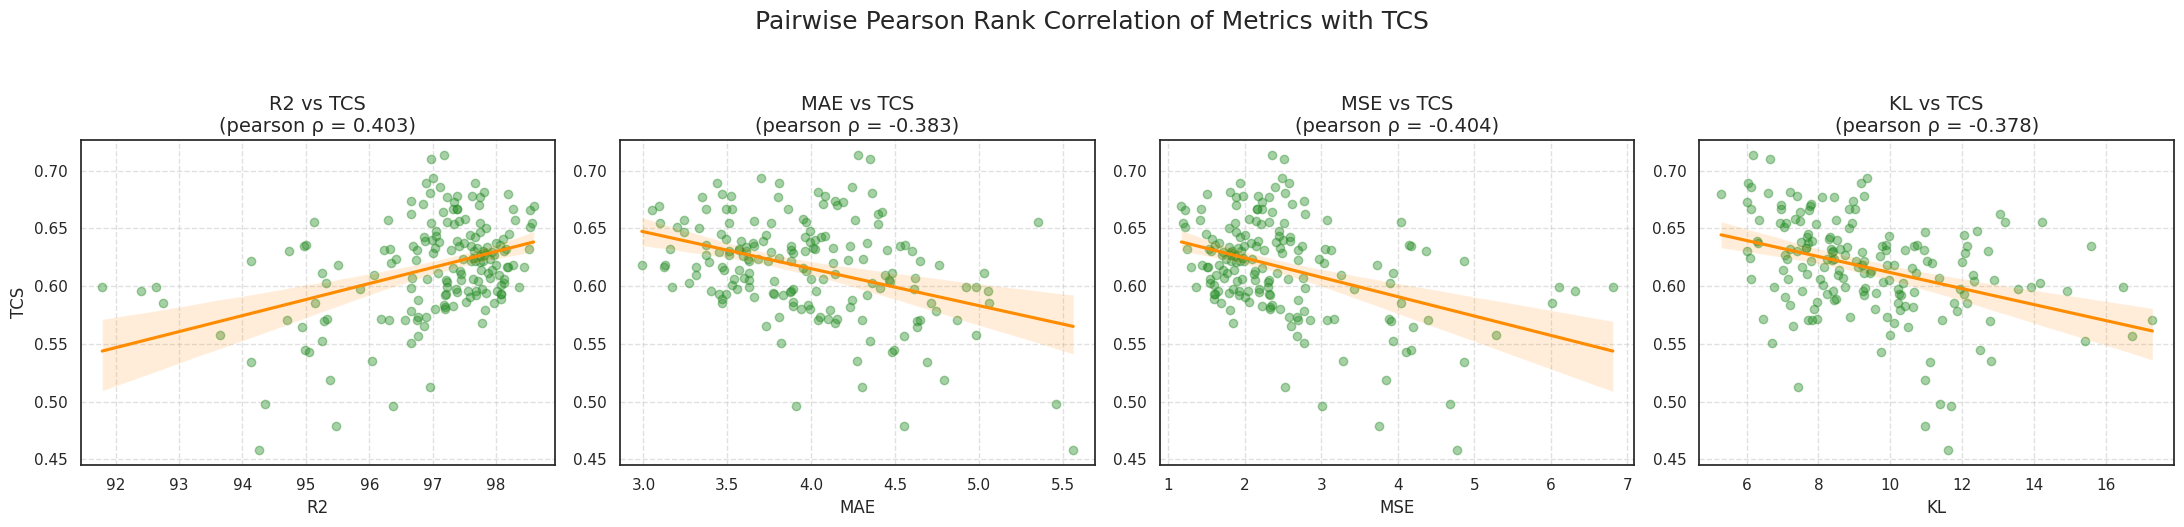

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Placeholder columns
metrics = ["R2", "MAE", "MSE", "KL", "TCS"]

# Set style
sns.set_theme(style="white")


# Define a function to create the plots to keep it clean
def plot_correlations(df, target_col="TCS", method="spearman"):
    metrics = ["R2", "MAE", "MSE", "KL"]

    # Ensure columns are numeric
    df[metrics + [target_col]] = df[metrics + [target_col]].apply(
        pd.to_numeric, errors="coerce"
    )

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"Pairwise {method.capitalize()} Rank Correlation of Metrics with {target_col}",
        fontsize=18,
        y=1.05,
    )

    for i, metric in enumerate(metrics):
        # Calculate correlation using the specified method
        corr_val = df[metric].corr(df[target_col], method=method)

        sns.regplot(
            ax=axes[i],
            x=metric,
            y=target_col,
            data=df,
            scatter_kws={"alpha": 0.4, "color": "forestgreen"},
            line_kws={"color": "darkorange"},
        )

        axes[i].set_title(
            f"{metric} vs {target_col}\n({method} ρ = {corr_val:.3f})", fontsize=14
        )
        axes[i].set_xlabel(metric, fontsize=12)
        axes[i].set_ylabel(target_col if i == 0 else "", fontsize=12)
        axes[i].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_correlations(
    combined_metrics[
        (combined_metrics["Classifier"] != "Lookup Classifier")
        & (combined_metrics["Feature Scheme"] != "Diag. + Bckg.")
        & (combined_metrics["Classifier"] != "UXM")
        & (combined_metrics["KL"] < 20)
    ],
    method="pearson",
)